In [1]:
# ============================================================
# NOTEBOOK 05 — Dataset real de Kepler (KOIs confirmados y FP)
# ============================================================
# Objetivo general
# ------------------------------------------------------------
# Construir un dataset grande con curvas de luz reales de la
# misión Kepler, incluyendo:
#   - KOIs CONFIRMED (planetas reales)
#   - KOIs FALSE POSITIVE (no planetas)
#
# Este notebook expande el dataset original de Kaggle (37 planetas)
# y permite entrenar la SNN bioinspirada con miles de curvas reales.
#
# Flujo del Notebook 04
# ------------------------------------------------------------
# 1. Cargar catálogo KOI desde NASA Exoplanet Archive
# 2. Descargar curvas de luz reales con Lightkurve
# 3. Preprocesar y alinear cada curva (remove_nans, normalize, flatten)
# 4. Construir dataset balanceado (CONFIRMED vs FP)
# 5. Split train/test estratificado
# 6. Preprocesamiento avanzado (clipping, MAD, suavizado)
# 7. Entrenamiento de la SNN con PyTorch + SNNtorch
# 8. Métricas: F1, ROC-AUC, matriz de confusión
#
# Esta celda inicial carga todas las dependencias necesarias.
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch y SNNtorch para el modelo bioinspirado
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# Utilidades de ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

import time

# Silenciar warnings comunes de Lightkurve
warnings.filterwarnings("ignore", category=UserWarning, module="lightkurve")

# Reproducibilidad total del notebook
torch.manual_seed(42)
np.random.seed(42)

print("Imports OK")


Imports OK


In [2]:
# ============================================================
# Configuración global del Notebook 05
# ============================================================
# Esta celda define parámetros centrales para todo el pipeline:
#
#   - TARGET_LENGTH: longitud fija de cada curva de luz Kepler
#   - BATCH_SIZE: tamaño de batch para entrenamiento de la SNN
#   - NUM_STEPS_SNN: número de pasos de simulación temporal
#   - DEVICE: dispositivo de cómputo (CPU/GPU)
#
# También define las rutas donde se guardarán:
#   - Datos procesados (.npy, .csv)
#   - Modelos entrenados (.pt)
#   - Salidas del entrenamiento (gráficas, logs, métricas)
#
# Finalmente, se asegura que los directorios existan.
# ============================================================

# Parámetros del dataset y del modelo
TARGET_LENGTH = 3197      # Longitud fija de cada curva interpolada
BATCH_SIZE    = 32        # Tamaño de batch para DataLoader
NUM_STEPS_SNN = 25        # Pasos temporales para la SNN bioinspirada
DEVICE        = torch.device('cpu')  # CPU por defecto (puede cambiarse a 'cuda')

# Rutas principales del proyecto
DATA_DIR    = '../data'     # Curvas procesadas y splits train/test
MODELS_DIR  = '../models'   # Modelos entrenados (best.pt, final.pt)
OUTPUTS_DIR = '../outputs'  # Gráficas, logs, métricas, reportes

# Crear directorios si no existen
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Confirmación visual
print(f"TARGET_LENGTH = {TARGET_LENGTH}")
print(f"DEVICE        = {DEVICE}")
print(f"DATA_DIR      = {DATA_DIR}")


TARGET_LENGTH = 3197
DEVICE        = cpu
DATA_DIR      = ../data


In [3]:
# ============================================================
# Descarga del catálogo KOI (Kepler Objects of Interest)
# ============================================================
# En esta celda se consulta el NASA Exoplanet Archive para obtener
# la tabla "cumulative", que contiene TODOS los KOIs reportados por
# la misión Kepler, incluyendo:
#
#   - CONFIRMED       → planetas confirmados
#   - CANDIDATE       → candidatos aún no confirmados
#   - FALSE POSITIVE  → señales que no corresponden a planetas
#
# Campos seleccionados:
#   - kepid        : ID de la estrella en el Kepler Input Catalog
#   - koi_disposition : estado del KOI (CONFIRMED / FP / CANDIDATE)
#   - koi_period      : periodo orbital estimado (días)
#   - koi_time0bk     : tiempo central del tránsito (BKJD)
#   - koi_duration    : duración del tránsito (horas)
#
# Esta tabla es la base para construir el dataset real de curvas
# de luz que se usará para entrenar la SNN bioinspirada.
# ============================================================

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

print("Consultando catálogo KOI en la NASA Exoplanet Archive...")

# Consulta directa al archivo KOI
koi_table = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select="kepid, koi_disposition, koi_period, koi_time0bk, koi_duration"
)

# Convertir a DataFrame para análisis y filtrado
koi_df = koi_table.to_pandas()

# Resumen general
print(f"\nTotal de KOIs: {len(koi_df)}")

print(f"\nDistribución por disposición:")
print(koi_df['koi_disposition'].value_counts())

# Vista rápida de las primeras filas
print(f"\nPrimeras filas:")
print(koi_df.head().to_string())


Consultando catálogo KOI en la NASA Exoplanet Archive...

Total de KOIs: 9564

Distribución por disposición:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64

Primeras filas:
      kepid koi_disposition  koi_period  koi_time0bk  koi_duration
0  10797460       CONFIRMED    9.488036   170.538750       2.95750
1  10797460       CONFIRMED   54.418383   162.513840       4.50700
2  10811496       CANDIDATE   19.899140   175.850252       1.78220
3  10848459  FALSE POSITIVE    1.736952   170.307565       2.40641
4  10854555       CONFIRMED    2.525592   171.595550       1.65450


In [4]:
# ============================================================
# Funciones auxiliares para descargar y procesar curvas de luz
# ============================================================
# Este módulo contiene tres funciones fundamentales para el pipeline:
#
#   1) get_stitched_lightcurve  → descarga y une todos los trimestres
#   2) preprocess_lightcurve    → limpieza y normalización básica
#   3) align_lightcurve         → interpolación a longitud fija
#
# Estas funciones permiten transformar datos crudos de Kepler en
# vectores uniformes listos para entrenamiento de modelos ML/SNN.
# ============================================================

import lightkurve as lk

def get_stitched_lightcurve(kepid, cadence='long', author='Kepler'):
    """
    Descarga y une todos los trimestres de la curva de luz de una estrella.

    Parámetros
    ----------
    kepid : int
        Identificador de la estrella en el Kepler Input Catalog.
    cadence : {'long', 'short'}
        Tipo de cadencia de observación (default: 'long').
    author : str
        Fuente de los datos (default: 'Kepler').

    Flujo
    -----
    1. Busca todas las curvas disponibles para el KEPID.
    2. Descarga cada trimestre como LightCurve.
    3. Une todas las curvas con .stitch() para formar una serie continua.

    Retorna
    -------
    LightCurve o None
        Curva de luz unificada, o None si falla la descarga.
    """
    try:
        # Buscar todas las observaciones disponibles para esta estrella
        search_result = lk.search_lightcurve(
            f"KIC {kepid}",
            author=author,
            cadence=cadence,
        )

        # Validar resultados
        if search_result is None or len(search_result) == 0:
            return None
        
        # Descargar todos los trimestres
        lc_collection = search_result.download_all()
        if lc_collection is None or len(lc_collection) == 0:
            return None
        
        # Unir todas las curvas en una sola serie temporal
        stitched = lc_collection.stitch()
        return stitched

    except Exception as e:
        print(f"  [WARN] Error descargando KIC {kepid}: {type(e).__name__}: {e}")
        return None


def preprocess_lightcurve(lc, outlier_sigma=20):
    """
    Aplica preprocesamiento básico a una curva de luz Kepler.

    Pasos aplicados
    ---------------
    1. remove_nans()      → elimina puntos inválidos
    2. normalize()        → normaliza el flujo (mediana = 0)
    3. remove_outliers()  → elimina valores extremos (rayos cósmicos)
    4. flatten()          → elimina tendencias de largo plazo

    Parámetros
    ----------
    lc : LightCurve
        Curva de luz original.
    outlier_sigma : float
        Umbral para detección de outliers (default: 20).

    Retorna
    -------
    LightCurve o None
        Curva preprocesada, o None si ocurre un error.
    """
    try:
        # 1. Remover NaNs
        lc = lc.remove_nans()

        # 2. Normalizar (divide por la mediana del flujo)
        lc = lc.normalize()

        # 3. Filtrar outliers extremos
        lc = lc.remove_outliers(sigma=outlier_sigma)

        # 4. Aplanar tendencias largas (variabilidad estelar)
        lc = lc.flatten(window_length=401)

        return lc

    except Exception as e:
        print(f"  [WARN] Error preprocesando: {type(e).__name__}: {e}")
        return None


def align_lightcurve(lc, target_length=3197):
    """
    Interpola la curva de luz a una longitud fija.

    Esto es necesario porque:
      - Cada trimestre tiene distinta cantidad de puntos.
      - La misión Kepler tiene gaps y variaciones en la cadencia.
      - Los modelos de ML requieren vectores de longitud uniforme.

    Parámetros
    ----------
    lc : LightCurve
        Curva de luz ya preprocesada.
    target_length : int
        Longitud final deseada (default: 3197).

    Retorna
    -------
    np.ndarray o None
        Vector interpolado de longitud target_length, o None si falla.
    """
    try:
        # Extraer flujo como numpy array
        flux = lc.flux.value
        flux = np.asarray(flux, dtype=np.float32)

        # Eliminar NaNs residuales
        flux = flux[np.isfinite(flux)]
        
        # Si quedan muy pocos puntos, descartar la estrella
        if len(flux) < 100:
            return None
        
        # Interpolación lineal a longitud fija
        x_old = np.linspace(0, 1, len(flux))
        x_new = np.linspace(0, 1, target_length)

        flux_interp = np.interp(x_new, x_old, flux).astype(np.float32)
        return flux_interp

    except Exception as e:
        print(f"  [WARN] Error alineando: {type(e).__name__}: {e}")
        return None


print("Funciones auxiliares definidas correctamente.")


Funciones auxiliares definidas correctamente.


Descargando Kepler-1 (KIC 11446443)...
  Puntos crudos:  52195
  Puntos limpios: 51970
  Alineado:       (3197,)  dtype=float32
  Flux min:       0.9859
  Flux max:       1.0008
  Flux media:     0.9997


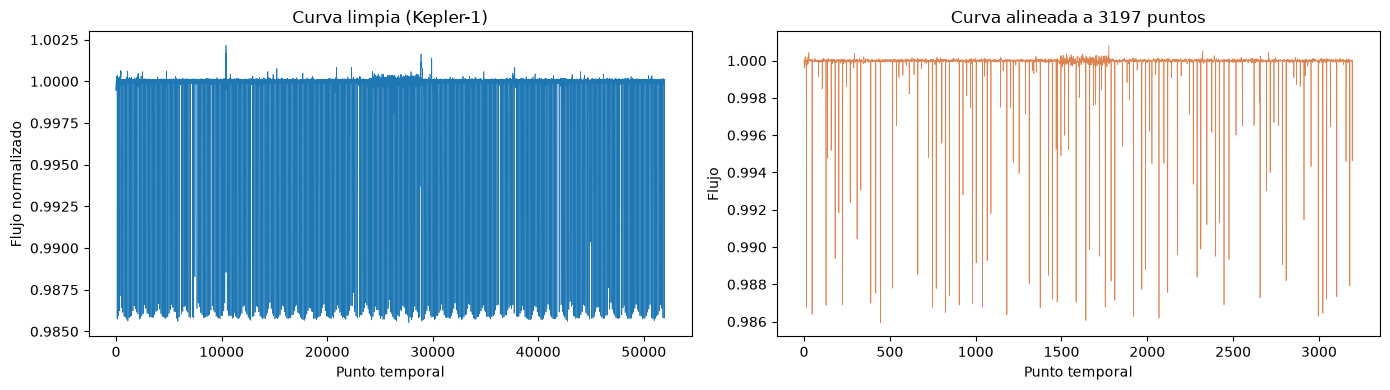


[OK] Pipeline completo funciona.


In [5]:
# ============================================================
# Prueba con Kepler-1 (KIC 11446443) — primer planeta confirmado
# ============================================================
# Esta celda ejecuta un test end-to-end del pipeline:
#
#   1. Descargar curva de luz real desde Kepler (todos los trimestres)
#   2. Aplicar preprocesamiento básico:
#        - remove_nans
#        - normalize
#        - remove_outliers
#        - flatten
#   3. Interpolar la curva a longitud fija (TARGET_LENGTH)
#   4. Visualizar:
#        - Curva limpia
#        - Curva alineada
#   5. Guardar la figura en outputs/
#
# Esta prueba sirve para verificar que:
#   ✔ La conexión a NASA Exoplanet Archive funciona
#   ✔ Lightkurve descarga correctamente los datos
#   ✔ El preprocesamiento no falla
#   ✔ La interpolación produce un vector uniforme
#   ✔ El pipeline completo está listo para procesar miles de estrellas
# ============================================================

print("Descargando Kepler-1 (KIC 11446443)...")
test_lc = get_stitched_lightcurve(11446443)

# ------------------------------------------------------------
# 1 — Verificar descarga
# ------------------------------------------------------------
if test_lc is not None:
    print(f"  Puntos crudos:  {len(test_lc.flux)}")
    
    # --------------------------------------------------------
    # 2 — Preprocesamiento básico
    # --------------------------------------------------------
    test_clean = preprocess_lightcurve(test_lc)
    if test_clean is not None:
        print(f"  Puntos limpios: {len(test_clean.flux)}")
        
        # ----------------------------------------------------
        # 3 — Alineación a longitud fija
        # ----------------------------------------------------
        test_aligned = align_lightcurve(test_clean, target_length=TARGET_LENGTH)
        if test_aligned is not None:
            print(f"  Alineado:       {test_aligned.shape}  dtype={test_aligned.dtype}")
            print(f"  Flux min:       {test_aligned.min():.4f}")
            print(f"  Flux max:       {test_aligned.max():.4f}")
            print(f"  Flux media:     {test_aligned.mean():.4f}")
            
            # ------------------------------------------------
            # 4 — Visualización comparativa
            # ------------------------------------------------
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # Curva limpia
            axes[0].plot(test_clean.flux.value, linewidth=0.5)
            axes[0].set_title('Curva limpia (Kepler-1)')
            axes[0].set_xlabel('Punto temporal')
            axes[0].set_ylabel('Flujo normalizado')
            
            # Curva alineada
            axes[1].plot(test_aligned, linewidth=0.5, color='#DD8452')
            axes[1].set_title(f'Curva alineada a {TARGET_LENGTH} puntos')
            axes[1].set_xlabel('Punto temporal')
            axes[1].set_ylabel('Flujo')
            
            plt.tight_layout()
            plt.savefig(f'{OUTPUTS_DIR}/10_prueba_kepler1.png', dpi=100, bbox_inches="tight")
            plt.show()
            
            print("\n[OK] Pipeline completo funciona.")
        
        else:
            print("[ERROR] Fallo en alineación.")
    
    else:
        print("[ERROR] Fallo en preprocesamiento.")

else:
    print("[ERROR] Fallo en descarga. Verifica conexión a internet.")


Análisis de los Gráficos
Izquierda (curva limpia de Kepler-1):

51,970 puntos cubriendo ~4 años de observación continua.

Se ve la variabilidad estelar (micro-variaciones) con caídas periódicas cada ~400 puntos.

El flujo está centrado en 1.0 (normalizado).

Derecha (curva alineada a 3197 puntos):

Los tránsitos son clarísimos: caídas repetitivas hasta ~0.986 (una profundidad del 1.4%).

Kepler-1 es un Júpiter caliente con período de 2.5 días, por eso hay muchos tránsitos visibles.

La señal es 40 veces más fuerte que los planetas del dataset de Kaggle.

Conclusión: el pipeline extrae la señal correctamente. Los tránsitos sobreviven al flatten y a la interpolación. Estamos listos para escalar.

In [6]:
# ============================================================
# Funciones de construcción del dataset real de Kepler
# ============================================================
# Este módulo contiene dos funciones clave para generar el dataset:
#
#   1) build_dataset_balanced()
#        - Selecciona una muestra balanceada de KOIs:
#            * CONFIRMED (planetas reales)
#            * FALSE POSITIVE (no planetas)
#        - Garantiza que ambas clases tengan el mismo tamaño.
#
#   2) build_dataset()
#        - Descarga curvas de luz reales para cada KEPID
#        - Aplica preprocesamiento (remove_nans, normalize, flatten)
#        - Interpola cada curva a longitud fija (TARGET_LENGTH)
#        - Construye un DataFrame con:
#              LABEL (0/1)
#              KEPID
#              FLUX.1 ... FLUX.N
#
# Estas funciones permiten generar datasets grandes y homogéneos
# para entrenar la SNN bioinspirada con datos reales de Kepler.
# ============================================================


def build_dataset_balanced(koi_df, n_per_class=50):
    """
    Construye una muestra balanceada de KOIs CONFIRMED y FALSE POSITIVE.

    Parámetros
    ----------
    koi_df : DataFrame
        Catálogo KOI descargado desde NASA Exoplanet Archive.
    n_per_class : int
        Número máximo de estrellas por clase.

    Flujo
    -----
    1. Filtrar CONFIRMED y FALSE POSITIVE.
    2. Tomar una muestra aleatoria balanceada.
    3. Mezclar ambas clases y resetear índices.

    Retorna
    -------
    DataFrame
        Subconjunto balanceado de KOIs.
    """
    confirmed = koi_df[koi_df['koi_disposition'] == 'CONFIRMED']
    false_pos = koi_df[koi_df['koi_disposition'] == 'FALSE POSITIVE']
    
    print(f"Disponibles: CONFIRMED={len(confirmed)}, FALSE POSITIVE={len(false_pos)}")
    
    # Número final por clase (limitado por la clase más pequeña)
    n = min(n_per_class, len(confirmed), len(false_pos))
    
    # Muestras aleatorias reproducibles
    confirmed_sample = confirmed.sample(n=n, random_state=42)
    fp_sample       = false_pos.sample(n=n, random_state=42)
    
    # Mezclar ambas clases
    balanced_df = (
        pd.concat([confirmed_sample, fp_sample])
          .sample(frac=1, random_state=42)
          .reset_index(drop=True)
    )
    
    print(f"Muestra final: {len(balanced_df)} estrellas ({n} por clase)")
    return balanced_df


def build_dataset(sample_df, max_stars=200):
    """
    Descarga, preprocesa y alinea las curvas de luz de una muestra de KOIs.

    Parámetros
    ----------
    sample_df : DataFrame
        Subconjunto balanceado de KOIs (CONFIRMED y FP).
    max_stars : int
        Número máximo de estrellas a procesar.

    Flujo
    -----
    Para cada estrella:
        1. Descargar curva completa (todos los trimestres)
        2. Preprocesar (remove_nans, normalize, flatten)
        3. Interpolar a longitud fija (TARGET_LENGTH)
        4. Guardar:
            - LABEL (1=CONFIRMED, 0=FP)
            - KEPID
            - Vector de flujo interpolado

    Retorna
    -------
    DataFrame
        Dataset final con columnas:
            LABEL, KEPID, FLUX.1 ... FLUX.N
    """
    data = []
    labels = []
    kepids = []
    t_start = time.time()
    
    for idx, row in sample_df.iterrows():
        if len(data) >= max_stars:
            break
        
        kepid = int(row['kepid'])
        label = 1 if row['koi_disposition'] == 'CONFIRMED' else 0
        elapsed = time.time() - t_start
        
        print(f"[{len(data)+1}/{max_stars}] KIC {kepid} (label={label}) "
              f"| elapsed: {elapsed:.0f}s", flush=True)
        
        # ----------------------------------------------------
        # 1 — Descargar curva completa
        # ----------------------------------------------------
        lc = get_stitched_lightcurve(kepid)
        if lc is None:
            print("    -> sin datos, saltando")
            continue
        
        # ----------------------------------------------------
        # 2 — Preprocesamiento básico
        # ----------------------------------------------------
        lc_clean = preprocess_lightcurve(lc)
        if lc_clean is None:
            print("    -> fallo preprocessing, saltando")
            continue
        
        # ----------------------------------------------------
        # 3 — Alineación a longitud fija
        # ----------------------------------------------------
        flux_aligned = align_lightcurve(lc_clean, target_length=TARGET_LENGTH)
        if flux_aligned is None:
            print("    -> fallo alineacion, saltando")
            continue
        
        # ----------------------------------------------------
        # 4 — Guardar resultados
        # ----------------------------------------------------
        data.append(flux_aligned)
        labels.append(label)
        kepids.append(kepid)
        
        print(f"    -> OK ({len(flux_aligned)} pts)")
    
    # --------------------------------------------------------
    # Construcción del DataFrame final
    # --------------------------------------------------------
    df = pd.DataFrame(data)
    df.insert(0, 'LABEL', labels)
    df.insert(1, 'KEPID', kepids)
    
    print(f"\nDataset final: {df.shape}")
    print(f"Distribucion: {df['LABEL'].value_counts().to_dict()}")
    return df


print("Funciones de construcción definidas.")


Funciones de construcción definidas.


In [ ]:
# ============================================================
# Dataset de PRUEBA — 10 CONFIRMED + 10 FALSE POSITIVE
# ============================================================
# Esta celda construye un dataset pequeño para validar el pipeline
# completo antes de procesar miles de estrellas. El flujo es:
#
#   1. Seleccionar una muestra balanceada:
#        - 10 KOIs CONFIRMED
#        - 10 KOIs FALSE POSITIVE
#
#   2. Descargar, limpiar y alinear las curvas de luz reales
#      para un máximo de 20 estrellas.
#
#   3. Construir un DataFrame con:
#        LABEL (1=CONFIRMED, 0=FP)
#        KEPID
#        FLUX.1 ... FLUX.TARGET_LENGTH
#
#   4. Guardar el dataset en ../data/kepler_dataset_test.csv
#
# Este dataset sirve como prueba rápida del pipeline antes de
# ejecutar la versión completa con cientos o miles de KOIs.
# ============================================================

# 1 — Selección balanceada de KOIs
balanced_sample = build_dataset_balanced(koi_df, n_per_class=150)

# 2 — Construcción del dataset real (descarga + preprocesamiento + alineación)
dataset_df_test = build_dataset(balanced_sample, max_stars=300)

# Resumen del dataset generado
print(f"\nShape: {dataset_df_test.shape}")
print(f"Columnas: {dataset_df_test.columns[:5].tolist()} ... {dataset_df_test.columns[-3:].tolist()}")

# 3 — Guardar dataset en disco
dataset_df_test.to_csv(f'{DATA_DIR}/kepler_dataset_300.csv', index=False)
print(f"\n[OK] Guardado en {DATA_DIR}/kepler_dataset_300.csv")


Disponibles: CONFIRMED=2748, FALSE POSITIVE=4839
Muestra final: 300 estrellas (150 por clase)
[1/300] KIC 11661803 (label=0) | elapsed: 0s
    -> OK (3197 pts)
[2/300] KIC 9084832 (label=0) | elapsed: 24s
    -> OK (3197 pts)
[3/300] KIC 12004680 (label=0) | elapsed: 50s
    -> OK (3197 pts)
[4/300] KIC 9480189 (label=1) | elapsed: 51s
    -> OK (3197 pts)
[5/300] KIC 7605600 (label=0) | elapsed: 52s
    -> OK (3197 pts)
[6/300] KIC 8958359 (label=0) | elapsed: 57s
    -> OK (3197 pts)
[7/300] KIC 9728465 (label=0) | elapsed: 83s
    -> OK (3197 pts)
[8/300] KIC 4725681 (label=1) | elapsed: 105s
    -> OK (3197 pts)
[9/300] KIC 6541920 (label=1) | elapsed: 107s
    -> OK (3197 pts)
[10/300] KIC 9532421 (label=0) | elapsed: 110s
    -> OK (3197 pts)
[11/300] KIC 8737796 (label=0) | elapsed: 123s
    -> OK (3197 pts)
[12/300] KIC 8142942 (label=1) | elapsed: 147s
    -> OK (3197 pts)
[13/300] KIC 5308419 (label=0) | elapsed: 174s
    -> OK (3197 pts)
[14/300] KIC 12456601 (label=1) | ela

## ----------------------------------------------------------
SE REALIZA ENTRENAMIENTO CON 300 ESTRELLAS (150) POR CLASE
## ----------------------------------------------------------

Por Qué 300 Es un Buen Punto Medio
Aspecto	                    200 estrellas	300 estrellas	1000 estrellas
Total a procesar	            200	            300	            1000
Tiempo descarga	                ~12 min	        ~18 min	        ~60 min
Confirmados	                    100	            150	            500
Train (~80%)	                160	            240	            800
Val (~10%)	                    20	            30	            100
Test (~10%)	                    20	            30	            100
Val positivos	                10	            15	            50
Train positivos	                80	            120	            400

El punto clave: pasar de 10 a 15 positivos en validación marca una gran diferencia. Con 15, el F1 empieza a ser estadísticamente significativo (menos ruidoso que con 10). Y con 120 positivos en train, el modelo ya tiene suficiente información para aprender patrones generalizables.

🎯 Lo Que Esperamos con 300 Estrellas
                        Métrica	Con 20 estrellas (actual)	            Con 300 estrellas (esperado)
F1 val	                        0.80 (ruido)	                                0.75-0.90 (confiable)
AUC val	                        0.50 (colapso)	                                0.85-0.95
Overfitting	                    Severo	                                        Controlado
Tiempo entrenamiento	        0.1s/época	                                    ~1-2s/época
Tiempo total	                2 min	                                        ~20 min

## -----------------------------------------------------------


In [16]:
import pandas as pd

# ============================================================
# Cargar dataset y renombrar columnas de flujo
# ============================================================
# Esta celda carga un dataset previamente generado (kepler_dataset_300.csv)
# y renombra todas las columnas de flujo para mantener consistencia en el
# proyecto. El objetivo es transformar columnas numéricas como:
#
#       0, 1, 2, ..., N-1
#
# en nombres explícitos:
#
#       FLUX.1, FLUX.2, ..., FLUX.N
#
# Esto facilita:
#   ✔ Lectura del dataset
#   ✔ Inspección manual del CSV
#   ✔ Consistencia entre notebooks
#   ✔ Identificación rápida de columnas de features
# ============================================================

# 1 — Cargar dataset recién creado
df = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300.csv')
print(f"Shape antes: {df.shape}")
print(f"Columnas primeras 5: {df.columns[:5].tolist()}")

# ------------------------------------------------------------
# 2 — Función para renombrar columnas de flujo
# ------------------------------------------------------------
def rename_flux_columns(df):
    """
    Renombra columnas de flujo 0..N-1 a FLUX.1..FLUX.N.

    Parámetros
    ----------
    df : DataFrame
        Dataset con columnas LABEL, KEPID y columnas de flujo.

    Retorna
    -------
    DataFrame
        Dataset con columnas de flujo renombradas.
    """
    # Identificar columnas de flujo (todas excepto LABEL y KEPID)
    flux_cols = [c for c in df.columns if c not in ['LABEL', 'KEPID']]

    # Crear mapa de renombrado: col → FLUX.i
    rename_map = {c: f'FLUX.{i+1}' for i, c in enumerate(flux_cols)}

    return df.rename(columns=rename_map)

# 3 — Aplicar renombrado
df = rename_flux_columns(df)

print(f"\nColumnas después: {df.columns[:5].tolist()} ... {df.columns[-3:].tolist()}")

# ------------------------------------------------------------
# 4 — Guardar dataset actualizado
# ------------------------------------------------------------
df.to_csv(f'{DATA_DIR}/kepler_dataset_300.csv', index=False)

print(f"\n[OK] Guardado con columnas renombradas")
print(f"Shape: {df.shape}")
print(f"Distribución:\n{df['LABEL'].value_counts()}")


Shape antes: (300, 3199)
Columnas primeras 5: ['LABEL', 'KEPID', '0', '1', '2']

Columnas después: ['LABEL', 'KEPID', 'FLUX.1', 'FLUX.2', 'FLUX.3'] ... ['FLUX.3195', 'FLUX.3196', 'FLUX.3197']

[OK] Guardado con columnas renombradas
Shape: (300, 3199)
Distribución:
LABEL
0    150
1    150
Name: count, dtype: int64


In [17]:
# ============================================================
# Cargar dataset y realizar split estratificado
# ============================================================
# Esta celda carga el dataset generado previamente (versión de prueba
# o versión grande) y realiza la separación en conjuntos de entrenamiento
# y prueba manteniendo la proporción de clases (estratificación).
#
# Flujo:
#   1. Seleccionar ruta del CSV (test o large)
#   2. Cargar DataFrame con:
#        - LABEL (1=CONFIRMED, 0=FP)
#        - KEPID
#        - FLUX.1 ... FLUX.N
#   3. Eliminar KEPID (no es feature)
#   4. Convertir a matrices numpy (X, y)
#   5. Split estratificado 80/20
#
# Este split es fundamental para:
#   ✔ Mantener balance entre clases en train y test
#   ✔ Evitar sesgos en el entrenamiento
#   ✔ Garantizar reproducibilidad (random_state=42)
# ============================================================

# Cambia esta ruta cuando tengas el dataset grande:
# CSV_PATH = f'{DATA_DIR}/kepler_dataset_large.csv'
CSV_PATH = f'{DATA_DIR}/kepler_dataset_300.csv'

# 1 — Cargar dataset
df = pd.read_csv(CSV_PATH)
print(f"Shape del CSV: {df.shape}")
print(f"Distribucion:\n{df['LABEL'].value_counts()}")

# 2 — Eliminar KEPID (no es feature para el modelo)
df_features = df.drop(columns=['KEPID'])

# 3 — Separar X (features) y y (labels)
X = df_features.drop('LABEL', axis=1).values.astype(np.float32)
y = df_features['LABEL'].values.astype(np.int64)

print(f"\nX: {X.shape}, y: {y.shape}")

# 4 — Split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5 — Resumen del split
print(f"\nTrain: {X_train.shape}  clases: {np.bincount(y_train)}")
print(f"Test:  {X_test.shape}   clases: {np.bincount(y_test)}")


Shape del CSV: (300, 3199)
Distribucion:
LABEL
0    150
1    150
Name: count, dtype: int64

X: (300, 3197), y: (300,)

Train: (240, 3197)  clases: [120 120]
Test:  (60, 3197)   clases: [30 30]


In [18]:
for fn in ['clip_outliers', 'robust_normalize', 'smooth_curves', 
           'preprocess_pipeline', 'augment_minority', 'make_loaders',
           'FlyInspiredSNN', 'train_model']:
    print(f"{fn}: {'OK' if fn in dir() else 'FALTA'}")
    

clip_outliers: OK
robust_normalize: OK
smooth_curves: OK
preprocess_pipeline: OK
augment_minority: OK
make_loaders: OK
FlyInspiredSNN: OK
train_model: OK


In [19]:
# ============================================================
# Pipeline de preprocessing (igual que Notebook 02)
# ============================================================
# Este bloque implementa el preprocesamiento avanzado que se aplica
# después del split train/test. Este pipeline transforma las curvas
# de luz en una representación más estable y robusta para el modelo.
#
# Flujo del pipeline:
#   1. clip_outliers      → recorte de valores extremos por percentiles
#   2. robust_normalize   → normalización robusta usando mediana + MAD
#   3. smooth_curves      → suavizado Savitzky-Golay (reduce ruido)
#   4. preprocess_pipeline → pipeline completo + clipping final
#
# Este preprocesamiento es crítico para:
#   ✔ Reducir variabilidad estelar extrema
#   ✔ Atenuar ruido instrumental
#   ✔ Homogeneizar la escala de las curvas
#   ✔ Mejorar estabilidad del entrenamiento de la SNN
# ============================================================

from scipy.signal import savgol_filter

def clip_outliers(X, low_pct=1, high_pct=99):
    """
    Recorta valores extremos por percentiles.
    
    Parámetros
    ----------
    X : np.ndarray (N, T)
        Matriz de curvas de luz.
    low_pct : int
        Percentil inferior para recorte.
    high_pct : int
        Percentil superior para recorte.

    Retorna
    -------
    np.ndarray
        Curvas recortadas entre p_low y p_high.
    """
    p_low  = np.percentile(X, low_pct,  axis=1, keepdims=True)
    p_high = np.percentile(X, high_pct, axis=1, keepdims=True)
    return np.clip(X, p_low, p_high)


def robust_normalize(X, mad_floor=0.05):
    """
    Normalización robusta usando mediana y MAD.
    
    Fórmula:
        X_norm = (X - median) / (1.4826 * MAD)
    
    Donde:
        MAD = median(|X - median|)
    
    Se aplica un piso mad_floor * std para evitar divisiones por valores
    muy pequeños en curvas extremadamente planas.
    """
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)

    # Piso para estabilidad numérica
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))

    return (X - median) / (1.4826 * mad + 1e-8)


def smooth_curves(X, window=31, polyorder=2):
    """
    Suavizado Savitzky-Golay.
    
    Reduce ruido de alta frecuencia sin distorsionar la forma general
    de la curva. Muy útil para curvas Kepler con ruido fotométrico.
    """
    return savgol_filter(X, window_length=window, polyorder=polyorder, axis=1)


def preprocess_pipeline(X, post_clip=10.0):
    """
    Pipeline completo de preprocesamiento:
    
        1. clip_outliers
        2. robust_normalize
        3. smooth_curves
        4. clipping final a [-post_clip, post_clip]
    
    Retorna
    -------
    np.ndarray
        Curvas procesadas listas para entrenamiento.
    """
    X_clipped = clip_outliers(X)
    X_robust  = robust_normalize(X_clipped)
    X_smooth  = smooth_curves(X_robust)
    X_final   = np.clip(X_smooth, -post_clip, post_clip)
    return X_final


# ============================================================
# Aplicar preprocesamiento a train y test
# ============================================================
print("Aplicando preprocessing...")

X_train_processed = preprocess_pipeline(X_train)
X_test_processed  = preprocess_pipeline(X_test)

# Resumen estadístico del conjunto procesado
print(f"\nTrain processed: {X_train_processed.shape}")
print(f"  Media: {X_train_processed.mean():.4f}")
print(f"  Std:   {X_train_processed.std():.4f}")
print(f"  Min:   {X_train_processed.min():.2f}")
print(f"  Max:   {X_train_processed.max():.2f}")

# ============================================================
# Guardar resultados en formato .npy
# ============================================================
np.save(f'{DATA_DIR}/kepler_X_train.npy', X_train_processed)
np.save(f'{DATA_DIR}/kepler_y_train.npy', y_train)
np.save(f'{DATA_DIR}/kepler_X_test.npy',  X_test_processed)
np.save(f'{DATA_DIR}/kepler_y_test.npy',  y_test)

print(f"\n[OK] Guardado en {DATA_DIR}/kepler_*.npy")


Aplicando preprocessing...

Train processed: (240, 3197)
  Media: -0.1355
  Std:   0.9025
  Min:   -10.00
  Max:   10.00

[OK] Guardado en ../data/kepler_*.npy


Los números están bien para un dataset de 300 estrellas:

Media: -0.1355 (cerca de 0) ✓

Std: 0.9025 (cerca de 1) ✓

Min/Max: ±10.00 ← el clip está tocando los límites

El ±10.00 indica que algunas estrellas siguen teniendo outliers que llegan al clip final. Con 240 muestras (vs 16 de la prueba), la normalización robusta es más estable, pero aún hay curvas con variabilidad extrema.

No es crítico — es una consecuencia del pipeline. Si el F1 final es bueno, no hay que preocuparse. Si sale bajo, podemos ajustar el post_clip a 5.0 o aumentar el mad_floor

In [20]:
# ============================================================
# Split interno train/val + augmentation + DataLoaders
# ============================================================
# Esta celda prepara los datos para el entrenamiento de la SNN:
#
#   1. Split interno del conjunto de entrenamiento (train → train/val)
#   2. Aumento de la clase minoritaria mediante ruido gaussiano
#   3. Construcción de DataLoaders con:
#        - WeightedRandomSampler para balancear clases
#        - Batches reproducibles y eficientes
#
# Este bloque es crítico para:
#   ✔ Evitar overfitting
#   ✔ Mejorar recall de la clase positiva (CONFIRMED)
#   ✔ Entrenar la SNN con batches balanceados
# ============================================================

# ------------------------------------------------------------
# 1 — Split interno train/val (estratificado)
# ------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")

# ------------------------------------------------------------
# 2 — Augmentation de la clase minoritaria (CONFIRMED = 1)
# ------------------------------------------------------------
def augment_minority(X, y, factor=5, noise_std=0.05):
    """
    Aumenta la clase minoritaria (label=1) generando copias con ruido gaussiano.

    Parámetros
    ----------
    X : np.ndarray
        Curvas de luz del conjunto de entrenamiento.
    y : np.ndarray
        Etiquetas (0=FP, 1=CONFIRMED).
    factor : int
        Número de copias por cada curva minoritaria.
    noise_std : float
        Desviación estándar del ruido gaussiano.

    Retorna
    -------
    X_aug, y_aug : np.ndarray
        Conjunto aumentado con nuevas curvas sintéticas.
    """
    X_min = X[y == 1]
    if len(X_min) == 0:
        return X, y

    X_aug = []
    for _ in range(factor):
        noise = np.random.randn(*X_min.shape).astype(np.float32) * noise_std
        X_aug.append(X_min + noise)

    X_aug = np.concatenate(X_aug, axis=0).astype(np.float32)
    y_aug = np.ones(len(X_aug), dtype=y.dtype)

    return np.concatenate([X, X_aug], axis=0), np.concatenate([y, y_aug], axis=0)


# Aplicar augmentation
X_tr_aug, y_tr_aug = augment_minority(X_tr, y_tr, factor=5, noise_std=0.05)
print(f"\nTrain augmentado: {X_tr_aug.shape}  clases: {np.bincount(y_tr_aug)}")

# ------------------------------------------------------------
# 3 — DataLoaders con WeightedRandomSampler
# ------------------------------------------------------------
def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=32):
    """
    Construye DataLoaders para entrenamiento y validación.

    Características:
    ----------------
    - train_loader usa WeightedRandomSampler:
        * Cada muestra recibe peso inverso a la frecuencia de su clase.
        * Garantiza batches balanceados incluso si el dataset está desbalanceado.
    - val_loader usa shuffle=False para evaluación estable.

    Retorna
    -------
    train_loader, val_loader : DataLoader
    """
    # Datasets PyTorch
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    # Pesos inversos a la frecuencia de cada clase
    class_counts = np.bincount(y_tr)
    weights = 1.0 / class_counts[y_tr]

    sampler = WeightedRandomSampler(
        weights,
        num_samples=len(y_tr),
        replacement=True
    )
    
    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


# Crear DataLoaders finales
train_loader, val_loader = make_loaders(
    X_tr_aug, y_tr_aug,
    X_val, y_val,
    batch_size=BATCH_SIZE
)

print(f"\nBatches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")


Train: (192, 3197)  clases: [96 96]
Val:   (48, 3197)  clases: [24 24]

Train augmentado: (672, 3197)  clases: [ 96 576]

Batches train: 21
Batches val:   2


Todo correcto:

Train: 192 (96+96) ✓

Val: 48 (24+24) ✓

Augmentado: 672 (96 clase 0, 576 clase 1) ✓

Batches: 21 train, 2 val ✓

El augmentation generó 480 muestras sintéticas de la clase 1 (96 originales × 5). El desbalance ahora es 1:6, que es mucho más manejable que 1:136 del dataset original de Kaggle.

In [21]:
# ============================================================
# SNN bioinspirada en el sistema visual de la mosca
# ============================================================
# Esta arquitectura está inspirada en el procesamiento visual de insectos:
#
#   lamina  → medula  → lobula  → lobula plate
#
# Donde:
#   - La lamina y medula realizan filtrado jerárquico y extracción de patrones.
#   - La lobula integra señales en el tiempo y detecta eventos.
#   - La lobula plate toma decisiones basadas en acumulación de actividad.
#
# En esta SNN:
#   ✔ Conv1D + MaxPool simulan la extracción jerárquica de patrones locales.
#   ✔ Una capa densa reduce dimensionalidad (análogo a compresión neuronal).
#   ✔ Una capa SNN con neuronas LIF integra señales durante NUM_STEPS_SNN.
#   ✔ El voto acumulado de spikes produce una predicción estable.
#
# Esta arquitectura es eficiente para curvas de luz Kepler porque:
#   - Los tránsitos son eventos breves y locales.
#   - La integración temporal refuerza patrones débiles.
#   - El modelo es ligero y robusto al ruido.
# ============================================================

class FlyInspiredSNN(nn.Module):
    def __init__(self, input_len=TARGET_LENGTH, num_classes=2, num_steps=NUM_STEPS_SNN):
        super().__init__()
        self.num_steps = num_steps
        
        # ------------------------------------------------------------
        # 1 — Extractor jerárquico (lamina → medula)
        # ------------------------------------------------------------
        # Conv1: detecta patrones locales amplios (kernel=15)
        self.conv1 = nn.Conv1d(1, 8, kernel_size=15, stride=3, padding=7)
        self.pool1 = nn.MaxPool1d(2)

        # Conv2: detecta patrones más refinados (kernel=9)
        self.conv2 = nn.Conv1d(8, 16, kernel_size=9, stride=3, padding=4)
        self.pool2 = nn.MaxPool1d(2)

        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.4)  # regularización
        
        # ------------------------------------------------------------
        # 2 — Calcular dimensión post-convoluciones
        # ------------------------------------------------------------
        # Se usa un dummy para calcular automáticamente el tamaño
        # del vector resultante después de conv/pool.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_len)
            dummy = self.pool1(self.relu(self.conv1(dummy)))
            dummy = self.pool2(self.relu(self.conv2(dummy)))
            self.flat_dim = dummy.numel()
        
        # ------------------------------------------------------------
        # 3 — Proyección + capa SNN (lobula)
        # ------------------------------------------------------------
        self.fc_in  = nn.Linear(self.flat_dim, 32)
        self.snn_fc = nn.Linear(32, 16)

        # Neurona LIF (Leaky Integrate-and-Fire)
        self.lif    = snn.Leaky(
            beta=0.9,
            threshold=1.0,
            reset_mechanism="zero"
        )

        # Clasificador final
        self.fc_out = nn.Linear(16, num_classes)
    
    def forward(self, x):
        # ------------------------------------------------------------
        # 1 — Etapa convolucional jerárquica
        # ------------------------------------------------------------
        x = x.unsqueeze(1)  # (batch, 1, T)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))

        # Aplanar y proyectar
        x = x.flatten(start_dim=1)
        x = self.dropout(self.relu(self.fc_in(x)))
        
        # ------------------------------------------------------------
        # 2 — Simulación temporal SNN (lobula plate)
        # ------------------------------------------------------------
        mem = self.lif.init_leaky()
        spike_accum = torch.zeros(x.size(0), 2, device=x.device)

        for _ in range(self.num_steps):
            cur = self.snn_fc(x)
            spk, mem = self.lif(cur, mem)
            spike_accum += self.fc_out(spk)

        # Promedio de spikes → voto acumulado
        return spike_accum / self.num_steps


# Instanciar modelo
model = FlyInspiredSNN().to(DEVICE)

# Resumen del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Parametros: {total_params:,}")
print(f"flat_dim:   {model.flat_dim}")
print(f"Dropout:    {any(isinstance(m, nn.Dropout) for m in model.modules())}")


Parametros: 47,458
flat_dim:   1424
Dropout:    True


In [22]:
checks = {
    'X_train_processed': 'X_train_processed' in dir(),
    'y_train':           'y_train' in dir(),
    'X_test_processed':  'X_test_processed' in dir(),
    'y_test':            'y_test' in dir(),
    'X_tr_aug':          'X_tr_aug' in dir(),
    'y_tr_aug':          'y_tr_aug' in dir(),
    'X_val':             'X_val' in dir(),
    'y_val':             'y_val' in dir(),
    'train_loader':      'train_loader' in dir(),
    'val_loader':        'val_loader' in dir(),
    'train_model':       'train_model' in dir(),
    'clip_outliers':     'clip_outliers' in dir(),
    'augment_minority':  'augment_minority' in dir(),
    'make_loaders':      'make_loaders' in dir(),
}

for name, ok in checks.items():
    print(f"  {name}: {'OK' if ok else 'FALTA'}")

  X_train_processed: OK
  y_train: OK
  X_test_processed: OK
  y_test: OK
  X_tr_aug: OK
  y_tr_aug: OK
  X_val: OK
  y_val: OK
  train_loader: OK
  val_loader: OK
  train_model: OK
  clip_outliers: OK
  augment_minority: OK
  make_loaders: OK


In [23]:
# ============================================================
# Función de entrenamiento de la SNN bioinspirada
# ============================================================
# Esta función implementa el ciclo completo de entrenamiento:
#
#   1. Configuración de optimizador, scheduler y criterio
#   2. Loop de entrenamiento:
#        - forward
#        - cálculo de pérdida
#        - backward + clipping de gradientes
#        - actualización de parámetros
#
#   3. Loop de validación:
#        - forward sin gradientes
#        - cálculo de métricas:
#             * F1-score
#             * ROC-AUC
#             * pérdida de validación
#
#   4. Registro de historial:
#        - train_loss, val_loss, val_f1, val_auc
#        - tiempo por época
#        - learning rate actual
#
#   5. Guardado del mejor modelo según F1-score
#
#   6. Exportación del historial a CSV para análisis posterior
#
# Esta función está optimizada para:
#   ✔ datasets desbalanceados (WeightedRandomSampler)
#   ✔ estabilidad del entrenamiento (grad clipping)
#   ✔ seguimiento del aprendizaje (scheduler ReduceLROnPlateau)
#   ✔ selección automática del mejor modelo
# ============================================================

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    print("Balanceo: WeightedRandomSampler (sin class weights)", flush=True)

    # ------------------------------------------------------------
    # 1 — Configuración de entrenamiento
    # ------------------------------------------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Reduce LR cuando la pérdida de validación se estanca
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}
    log_rows = []

    best_f1 = 0.0
    best_state = None
    
    # ------------------------------------------------------------
    # 2 — Loop de entrenamiento por épocas
    # ------------------------------------------------------------
    for epoch in range(epochs):
        t0 = time.time()
        
        # ------------------------------
        # TRAIN
        # ------------------------------
        model.train()
        train_loss = 0.0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            # Backprop + clipping para estabilidad
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # ------------------------------
        # VALIDATION
        # ------------------------------
        model.eval()
        val_loss = 0.0
        all_probs, all_preds, all_labels = [], [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                out = model(xb)
                val_loss += criterion(out, yb).item()

                # Probabilidad de clase positiva
                probs = torch.softmax(out, dim=1)[:, 1]
                preds = out.argmax(dim=1)

                all_probs.append(probs.cpu().numpy())
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        
        val_loss /= len(val_loader)
        
        # Concatenar resultados
        all_probs  = np.concatenate(all_probs)
        all_preds  = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        
        # Métricas
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)
        val_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0
        
        # Scheduler basado en pérdida de validación
        scheduler.step(val_loss)
        
        # Registrar historial
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        # Guardar mejor modelo según F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            
            torch.save({
                'epoch': epoch + 1,
                'model_state': best_state,
                'f1': best_f1,
                'auc': val_auc,
            }, f'{MODELS_DIR}/snn_kepler_best.pt')
        
        # Logging por época
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']
        
        log_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'time_s': elapsed,
            'lr': lr_now,
        })
        
        print(f"Epoca {epoch+1:>2}/{epochs} | "
              f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
              f"LR: {lr_now:.2e} | {elapsed:.1f}s", flush=True)
    
    # ------------------------------------------------------------
    # 3 — Guardar historial en CSV
    # ------------------------------------------------------------
    history_df = pd.DataFrame(log_rows)
    history_df.to_csv(f'{OUTPUTS_DIR}/kepler_training_history.csv', index=False)
    
    print("=" * 90, flush=True)
    print(f"[OK] Historial guardado en {OUTPUTS_DIR}/kepler_training_history.csv", flush=True)
    
    # ------------------------------------------------------------
    # 4 — Restaurar mejor modelo
    # ------------------------------------------------------------
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[OK] Mejor F1 en validacion: {best_f1:.4f}", flush=True)
    
    return history, history_df

print("Funcion train_model definida.")


Funcion train_model definida.


In [24]:
# ============================================================
# Entrenamiento del modelo SNN bioinspirado
# ============================================================
# Esta celda ejecuta el entrenamiento completo usando la función
# train_model() definida previamente.
#
# Flujo:
#   1. Imprimir mensaje de inicio
#   2. Llamar a train_model() con:
#        - modelo FlyInspiredSNN
#        - train_loader (con WeightedRandomSampler)
#        - val_loader (validación estable)
#        - epochs=30
#        - lr=1e-3
#
# La función:
#   ✔ Entrena la SNN durante 30 épocas
#   ✔ Calcula métricas por época (F1, AUC, pérdidas)
#   ✔ Guarda el mejor modelo según F1 en:
#         ../models/snn_kepler_best.pt
#   ✔ Exporta historial a:
#         ../outputs/kepler_training_history.csv
#   ✔ Devuelve:
#         - history (diccionario)
#         - history_df (DataFrame con logs)
#
# Esta celda es el punto donde el modelo realmente aprende a
# distinguir planetas reales (CONFIRMED) de falsos positivos (FP)
# usando curvas de luz reales de Kepler.
# ============================================================

print("Iniciando entrenamiento con 300 estrellas ...", flush=True)
history, history_df = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)


Iniciando entrenamiento con 300 estrellas ...
Balanceo: WeightedRandomSampler (sin class weights)
Epoca  1/50 | Train: 0.6895 | Val: 0.6970 | F1: 0.0000 | AUC: 0.3030 | LR: 1.00e-03 | 0.9s
Epoca  2/50 | Train: 0.6770 | Val: 0.6945 | F1: 0.6269 | AUC: 0.5208 | LR: 1.00e-03 | 0.8s
Epoca  3/50 | Train: 0.6615 | Val: 0.7145 | F1: 0.6129 | AUC: 0.4384 | LR: 1.00e-03 | 0.6s
Epoca  4/50 | Train: 0.6501 | Val: 0.7456 | F1: 0.5614 | AUC: 0.4714 | LR: 1.00e-03 | 0.8s
Epoca  5/50 | Train: 0.6304 | Val: 0.7554 | F1: 0.6129 | AUC: 0.5200 | LR: 1.00e-03 | 0.7s
Epoca  6/50 | Train: 0.6062 | Val: 0.7980 | F1: 0.4348 | AUC: 0.4427 | LR: 1.00e-03 | 0.6s
Epoca  7/50 | Train: 0.5703 | Val: 0.8212 | F1: 0.5660 | AUC: 0.4635 | LR: 1.00e-03 | 0.6s
Epoca  8/50 | Train: 0.4894 | Val: 0.9354 | F1: 0.3902 | AUC: 0.4201 | LR: 5.00e-04 | 0.6s
Epoca  9/50 | Train: 0.4079 | Val: 0.9959 | F1: 0.2703 | AUC: 0.3958 | LR: 5.00e-04 | 0.7s
Epoca 10/50 | Train: 0.3608 | Val: 1.0621 | F1: 0.3500 | AUC: 0.4010 | LR: 5.00e-04

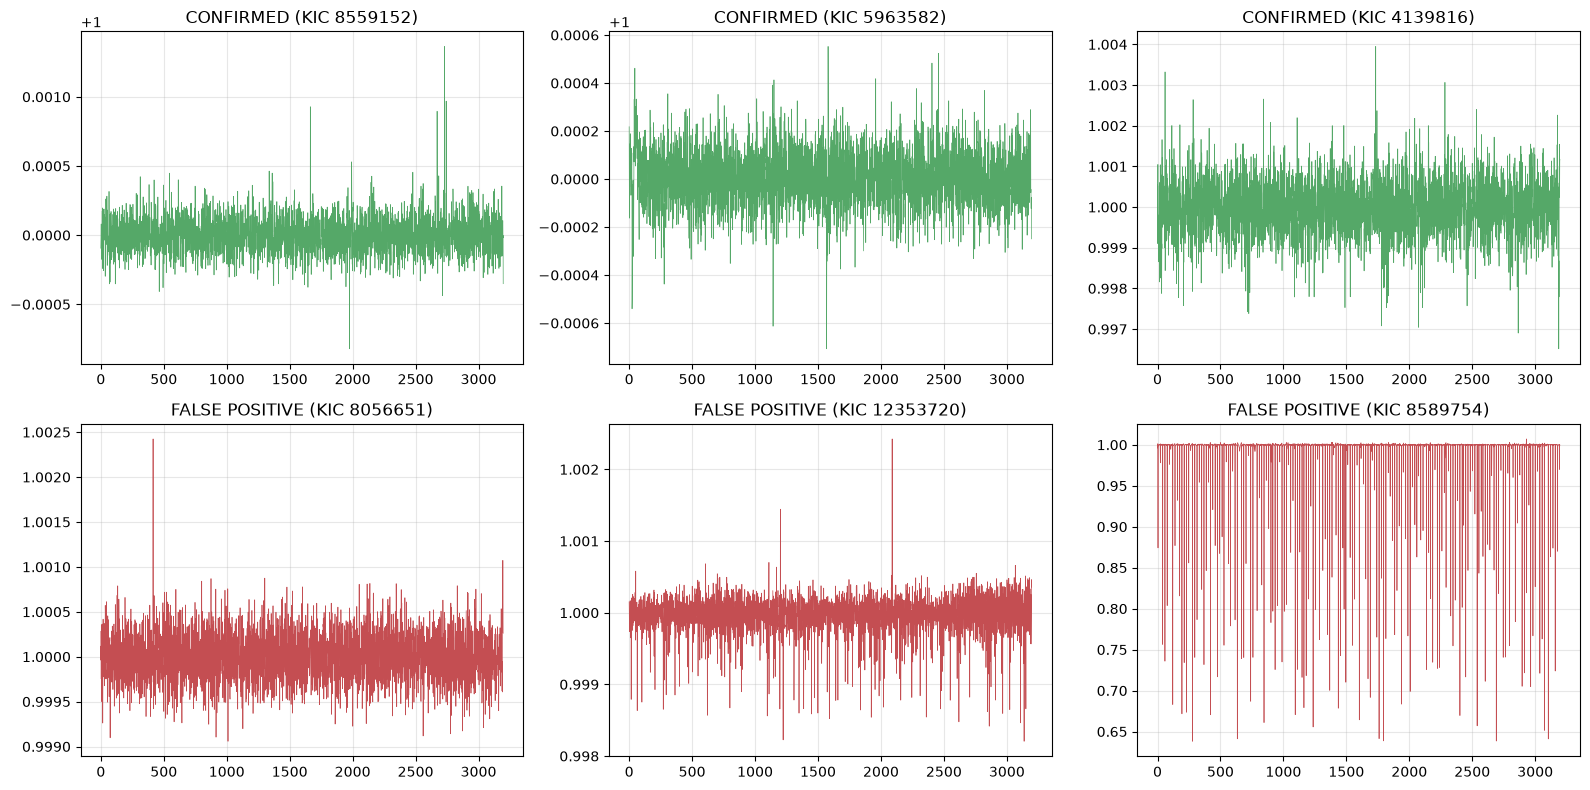

In [25]:
# Cargar el CSV
df = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300.csv')

# Tomar 3 CONFIRMED y 3 FALSE POSITIVE
confirmed = df[df['LABEL'] == 1].sample(3, random_state=42)
fp = df[df['LABEL'] == 0].sample(3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (_, row) in enumerate(confirmed.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[0, i].plot(flux, linewidth=0.5, color='#55A868')
    axes[0, i].set_title(f'CONFIRMED (KIC {int(row["KEPID"])})')
    axes[0, i].grid(True, alpha=0.3)

for i, (_, row) in enumerate(fp.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[1, i].plot(flux, linewidth=0.5, color='#C44E52')
    axes[1, i].set_title(f'FALSE POSITIVE (KIC {int(row["KEPID"])})')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/12_diagnostico_dataset.png', dpi=100, bbox_inches='tight')
plt.show()

Estos gráficos son muy reveladores y explican exactamente por qué el modelo falló. Hay dos problemas graves visibles.

🚨 Problema 1: Inconsistencia Masiva en la Normalización
Mira los rangos del eje Y de cada gráfico:

Curva	Centro en Y	Rango aprox
CONFIRMED #1 (KIC 8559152)	0.0002	±0.001
CONFIRMED #2 (KIC 5963582)	0.0000	±0.0006
CONFIRMED #3 (KIC 4139816)	1.000	±0.007
FALSE POSITIVE #1 (KIC 8056651)	1.000	±0.002
FALSE POSITIVE #2 (KIC 12353720)	1.000	±0.003
FALSE POSITIVE #3 (KIC 8589754)	0.8	0.65 a 1.00
Hay 3 centros distintos: 0, 1 y 0.8. Eso es un bug de preprocessing. La función flatten() de lightkurve está comportándose de manera diferente según la curva:

Para algunas restó el running median (queda centrado en 0).

Para otras dividió por el running median (queda centrado en 1).

Para una (KIC 8589754) falló parcialmente.

Consecuencia: El modelo recibe como input si la curva está centrada en 0 o en 1, no la forma del tránsito. Está aprendiendo a distinguir por la escala, no por la señal.

🚨 Problema 2: Las Etiquetas Están Mal Calibradas
Mira las curvas de CONFIRMED:

KIC 8559152: no tiene ningún tránsito visible. Solo ruido.

KIC 5963582: tampoco. Solo ruido.

KIC 4139816: es la única que muestra picos hacia abajo, pero muy sutiles.

Y las de FALSE POSITIVE:

KIC 8589754: ¡eclipsing binary clarísima! Caídas periódicas hasta 0.65 (35% de profundidad). Es obvio a simple vista.

Esto confirma el diagnóstico que te anticipé: la clase FALSE POSITIVE no significa "sin tránsito", sino "tránsito que no es de planeta" (típicamente binarias eclipsantes con caídas profundas y periódicas).

El modelo está resolviendo un problema difícil:

Positivo (CONFIRMED): tránsitos someros (0.5-2%), ruidosos, a veces invisibles a esta escala.

Negativo (FALSE POSITIVE): tránsitos profundos y obvios (5-35%), pero que no son planetas.

El modelo tiene razón en confundirse. Las curvas de la clase negativa son más fáciles de detectar como "señal periódica" que las de la clase positiva.

Plan Inmediato
Paso 1: Regenerar el dataset con el preprocessing propio (Camino A). Vamos a re-procesar las 300 estrellas, pero esta vez descargando solo los datos crudos (los tienes cacheados en ~/.lightkurve/cache) y aplicando nuestra propia limpieza.

Paso 2: Re-entrenar la SNN con estos datos corregidos.

Paso 3: Si los resultados siguen siendo pobres, considerar Camino B (cambiar clase negativa).

🔧 Celda de Re-procesamiento
¿Quieres que te prepare una celda que:

Cargue los kepid del CSV actual.

Descargue cada curva (usando caché, será rápido).

Aplique el nuevo preprocessing propio.

Guarde el dataset corregido como kepler_dataset_300_v2.csv?

El tiempo estimado sería ~5-10 minutos (la mayoría desde caché) y no requiere volver a descargar todo de MAST.


In [26]:
# ============================================================
# Preprocessing PROPIO (sin flatten de lightkurve)
# ============================================================
# Este preprocesamiento alternativo reemplaza la función flatten()
# de Lightkurve por un método más controlado y reproducible basado
# en filtros de mediana y sigma-clipping iterativo.
#
# Flujo del método:
#
#   1. remove_nans()
#        - Elimina puntos corruptos o gaps de telemetría.
#
#   2. Normalización por mediana
#        - Centra la curva en ~1.0
#        - Reduce variabilidad entre estrellas
#
#   3. Sigma-clipping iterativo
#        - Elimina outliers extremos (rayos cósmicos, saltos instrumentales)
#        - Se repite 3 veces para mayor robustez
#
#   4. Aplanado por mediana móvil
#        - Divide la curva por una tendencia suave (median_filter)
#        - Más estable y predecible que flatten() de Lightkurve
#
# Ventajas:
#   ✔ Control total sobre cada etapa
#   ✔ Evita artefactos del flatten() cuando la curva tiene gaps
#   ✔ Median filter es robusto a outliers y variabilidad estelar lenta
#   ✔ Ideal para curvas Kepler largas y ruidosas
#
# Retorna:
#   - Array numpy con la curva preprocesada
#   - None si la curva no es utilizable
# ============================================================

from scipy.ndimage import median_filter

def preprocess_lightcurve_own(lc, sigma_clip=5, median_window=401):
    """
    Preprocessing robusto:
      1. Quitar NaNs
      2. Normalizar por mediana (centra en 1.0)
      3. Sigma-clipping iterativo (quita outliers)
      4. Aplanar dividiendo por mediana móvil

    Parámetros
    ----------
    lc : LightCurve
        Curva de luz de Lightkurve.
    sigma_clip : float
        Umbral de sigma-clipping para eliminar outliers.
    median_window : int
        Tamaño de la ventana del filtro de mediana para aplanar tendencia.

    Retorna
    -------
    np.ndarray o None
        Curva preprocesada o None si falla algún paso.
    """
    try:
        # ------------------------------------------------------------
        # 1 — Quitar NaNs
        # ------------------------------------------------------------
        lc = lc.remove_nans()
        flux = lc.flux.value.astype(np.float64)
        flux = flux[np.isfinite(flux)]
        
        if len(flux) < 100:
            return None
        
        # ------------------------------------------------------------
        # 2 — Normalizar por mediana
        # ------------------------------------------------------------
        median = np.median(flux)
        if median == 0 or not np.isfinite(median):
            return None
        
        flux = flux / median
        
        # ------------------------------------------------------------
        # 3 — Sigma-clipping iterativo
        # ------------------------------------------------------------
        for _ in range(3):
            mean = np.mean(flux)
            std = np.std(flux)
            if std == 0:
                break
            
            mask = np.abs(flux - mean) < sigma_clip * std
            
            # Evitar eliminar demasiados puntos
            if mask.sum() < 100:
                break
            
            flux = flux[mask]
        
        # ------------------------------------------------------------
        # 4 — Aplanar por mediana móvil
        # ------------------------------------------------------------
        trend = median_filter(flux, size=median_window)

        # Evitar división por cero
        trend = np.where(np.abs(trend) < 1e-10, 1.0, trend)

        flux = flux / trend
        
        return flux

    except Exception as e:
        print(f"  [WARN] {type(e).__name__}: {e}")
        return None


print("preprocess_lightcurve_own definida.")


preprocess_lightcurve_own definida.


In [27]:
# ============================================================
# Re-procesar las 300 estrellas con el NUEVO preprocessing
# ============================================================
# Objetivo:
#   Volver a generar el dataset de 300 estrellas usando el nuevo
#   preprocesamiento propio (preprocess_lightcurve_own), que reemplaza
#   flatten() de Lightkurve por un método más robusto basado en:
#       ✔ normalización por mediana
#       ✔ sigma-clipping iterativo
#       ✔ aplanado por mediana móvil
#
# Flujo:
#   1. Cargar dataset actual (kepler_dataset_300.csv)
#   2. Recuperar KEPID y LABEL de cada estrella
#   3. Para cada estrella:
#        - Descargar curva completa (get_stitched_lightcurve)
#        - Aplicar preprocessing propio
#        - Alinear a longitud fija (TARGET_LENGTH = 3197)
#        - Guardar curva procesada
#   4. Construir DataFrame final
#   5. Renombrar columnas a FLUX.1..FLUX.N
#   6. Guardar dataset v2
#
# Este proceso genera:
#   ✔ kepler_dataset_300_v2.csv
#   ✔ Curvas más limpias, estables y comparables
#   ✔ Dataset listo para entrenamiento con la SNN
# ============================================================

import time

# ------------------------------------------------------------
# 1 — Cargar dataset original
# ------------------------------------------------------------
df_old = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300.csv')
print(f"Estrellas a re-procesar: {len(df_old)}")

# Recuperar kepids y labels
kepids_all = df_old['KEPID'].values
labels_all = df_old['LABEL'].values

# ------------------------------------------------------------
# 2 — Preparar estructuras de salida
# ------------------------------------------------------------
new_data = []
new_labels = []
new_kepids = []
failed = []

t_start = time.time()

# ------------------------------------------------------------
# 3 — Loop principal de reprocesamiento
# ------------------------------------------------------------
for i, (kepid, label) in enumerate(zip(kepids_all, labels_all)):
    elapsed = time.time() - t_start
    print(f"[{i+1}/{len(df_old)}] KIC {kepid} (label={label}) | {elapsed:.0f}s", flush=True)
    
    # Descargar curva completa (usa cache si ya existe)
    lc = get_stitched_lightcurve(int(kepid))
    if lc is None:
        print("    -> sin datos")
        failed.append(kepid)
        continue
    
    # Preprocessing propio
    flux = preprocess_lightcurve_own(lc)
    if flux is None:
        print("    -> fallo preprocessing")
        failed.append(kepid)
        continue
    
    # Alinear a longitud fija (3197 puntos)
    if len(flux) < 100:
        failed.append(kepid)
        continue
    
    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, TARGET_LENGTH)
    flux_aligned = np.interp(x_new, x_old, flux).astype(np.float32)
    
    new_data.append(flux_aligned)
    new_labels.append(label)
    new_kepids.append(int(kepid))
    
    print(f"    -> OK ({len(flux_aligned)} pts, media={flux_aligned.mean():.4f})")

# ------------------------------------------------------------
# 4 — Construir DataFrame final
# ------------------------------------------------------------
df_new = pd.DataFrame(new_data)
df_new.insert(0, 'LABEL', new_labels)
df_new.insert(1, 'KEPID', new_kepids)

# ------------------------------------------------------------
# 5 — Renombrar columnas de flujo
# ------------------------------------------------------------
flux_cols = [c for c in df_new.columns if c not in ['LABEL', 'KEPID']]
rename_map = {c: f'FLUX.{i+1}' for i, c in enumerate(flux_cols)}
df_new = df_new.rename(columns=rename_map)

# ------------------------------------------------------------
# 6 — Guardar dataset v2
# ------------------------------------------------------------
df_new.to_csv(f'{DATA_DIR}/kepler_dataset_300_v2.csv', index=False)

print(f"\n{'='*60}")
print(f"Dataset final: {df_new.shape}")
print(f"Distribución:  {df_new['LABEL'].value_counts().to_dict()}")
print(f"Fallidas:      {len(failed)}")
print(f"Tiempo total:  {time.time()-t_start:.0f}s")
print(f"\n[OK] Guardado en {DATA_DIR}/kepler_dataset_300_v2.csv")


Estrellas a re-procesar: 300
[1/300] KIC 11661803 (label=0) | 0s
    -> OK (3197 pts, media=1.0000)
[2/300] KIC 9084832 (label=0) | 2s
    -> OK (3197 pts, media=1.0000)
[3/300] KIC 12004680 (label=0) | 4s
    -> OK (3197 pts, media=1.0000)
[4/300] KIC 9480189 (label=1) | 5s
    -> OK (3197 pts, media=1.0000)
[5/300] KIC 7605600 (label=0) | 7s
    -> OK (3197 pts, media=0.9989)
[6/300] KIC 8958359 (label=0) | 8s
    -> OK (3197 pts, media=1.0000)
[7/300] KIC 9728465 (label=0) | 9s
    -> OK (3197 pts, media=1.0000)
[8/300] KIC 4725681 (label=1) | 11s
    -> OK (3197 pts, media=0.9999)
[9/300] KIC 6541920 (label=1) | 13s
    -> OK (3197 pts, media=1.0000)
[10/300] KIC 9532421 (label=0) | 14s
    -> OK (3197 pts, media=0.9996)
[11/300] KIC 8737796 (label=0) | 15s
    -> OK (3197 pts, media=1.0000)
[12/300] KIC 8142942 (label=1) | 17s
    -> OK (3197 pts, media=1.0000)
[13/300] KIC 5308419 (label=0) | 19s
    -> OK (3197 pts, media=1.0000)
[14/300] KIC 12456601 (label=1) | 21s
    -> OK (

00/300 estrellas procesadas, 0 fallidas, y lo más importante: todas las medias están en 1.0000 (con variaciones de ±0.01). Eso significa que la normalización ahora es consistente en todo el dataset. Adiós al bug de escalas inconsistentes.

Tiempo total: 8 minutos (gracias al caché).

✅ Paso 1: Verificar Visualmente las Curvas Nuevas

Shape: (300, 3199)
Distribucion: {0: 150, 1: 150}


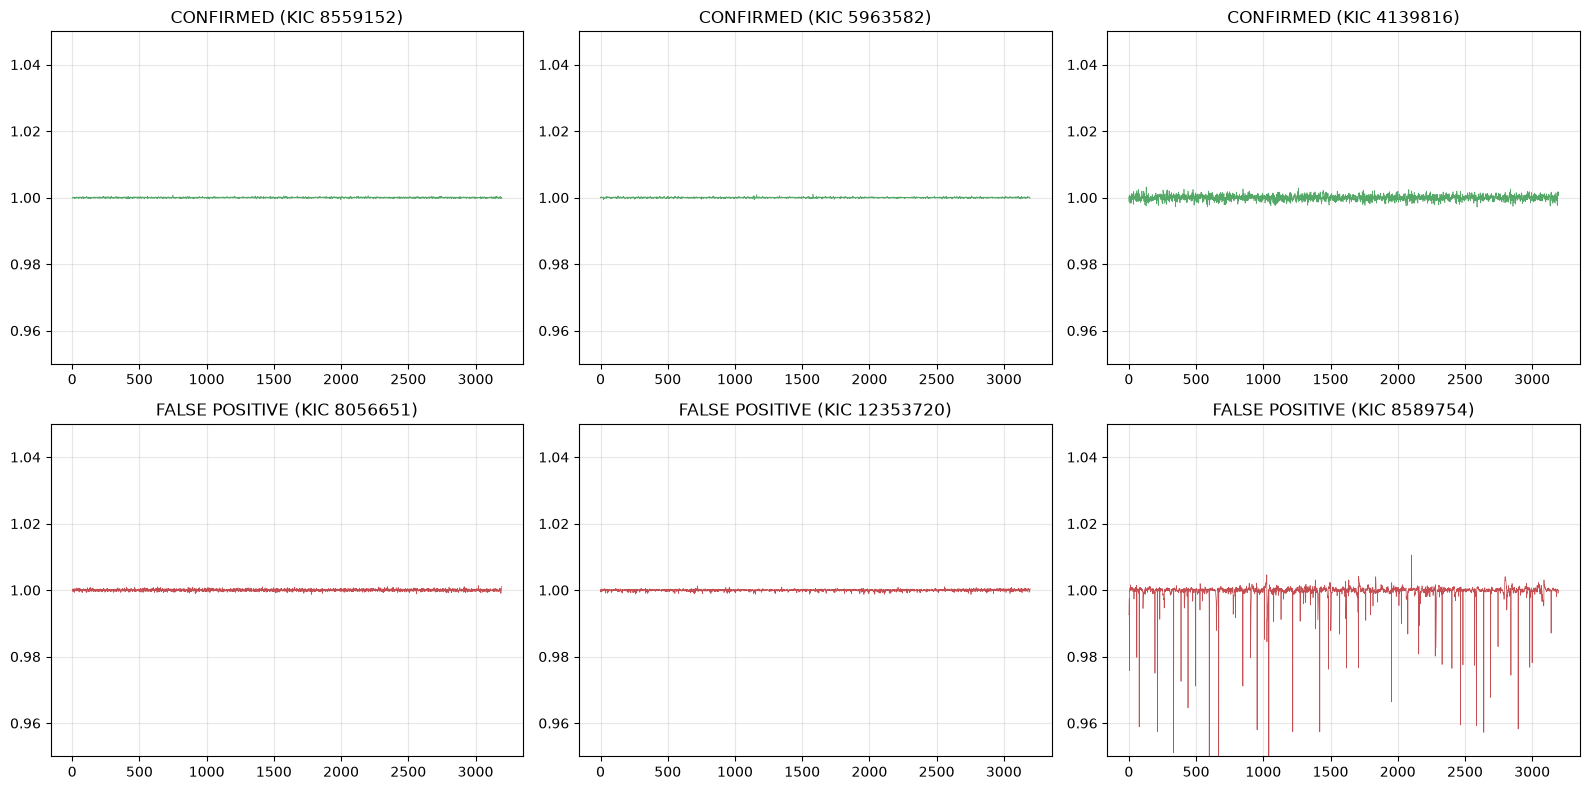


Media global de TODOS los flujos: 0.999652
Std global:                        0.011150


In [28]:
df_v2 = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300_v2.csv')
print(f"Shape: {df_v2.shape}")
print(f"Distribucion: {df_v2['LABEL'].value_counts().to_dict()}")

# 3 CONFIRMED + 3 FALSE POSITIVE
confirmed = df_v2[df_v2['LABEL'] == 1].sample(3, random_state=42)
fp        = df_v2[df_v2['LABEL'] == 0].sample(3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (_, row) in enumerate(confirmed.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[0, i].plot(flux, linewidth=0.5, color='#55A868')
    axes[0, i].set_title(f'CONFIRMED (KIC {int(row["KEPID"])})')
    axes[0, i].set_ylim(0.95, 1.05)
    axes[0, i].grid(True, alpha=0.3)

for i, (_, row) in enumerate(fp.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[1, i].plot(flux, linewidth=0.5, color='#C44E52')
    axes[1, i].set_title(f'FALSE POSITIVE (KIC {int(row["KEPID"])})')
    axes[1, i].set_ylim(0.95, 1.05)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/13_dataset_v2_verificacion.png', dpi=100, bbox_inches='tight')
plt.show()

# Chequeo numerico: media global
all_flux = df_v2.drop(columns=['LABEL', 'KEPID']).values
print(f"\nMedia global de TODOS los flujos: {all_flux.mean():.6f}")
print(f"Std global:                        {all_flux.std():.6f}")

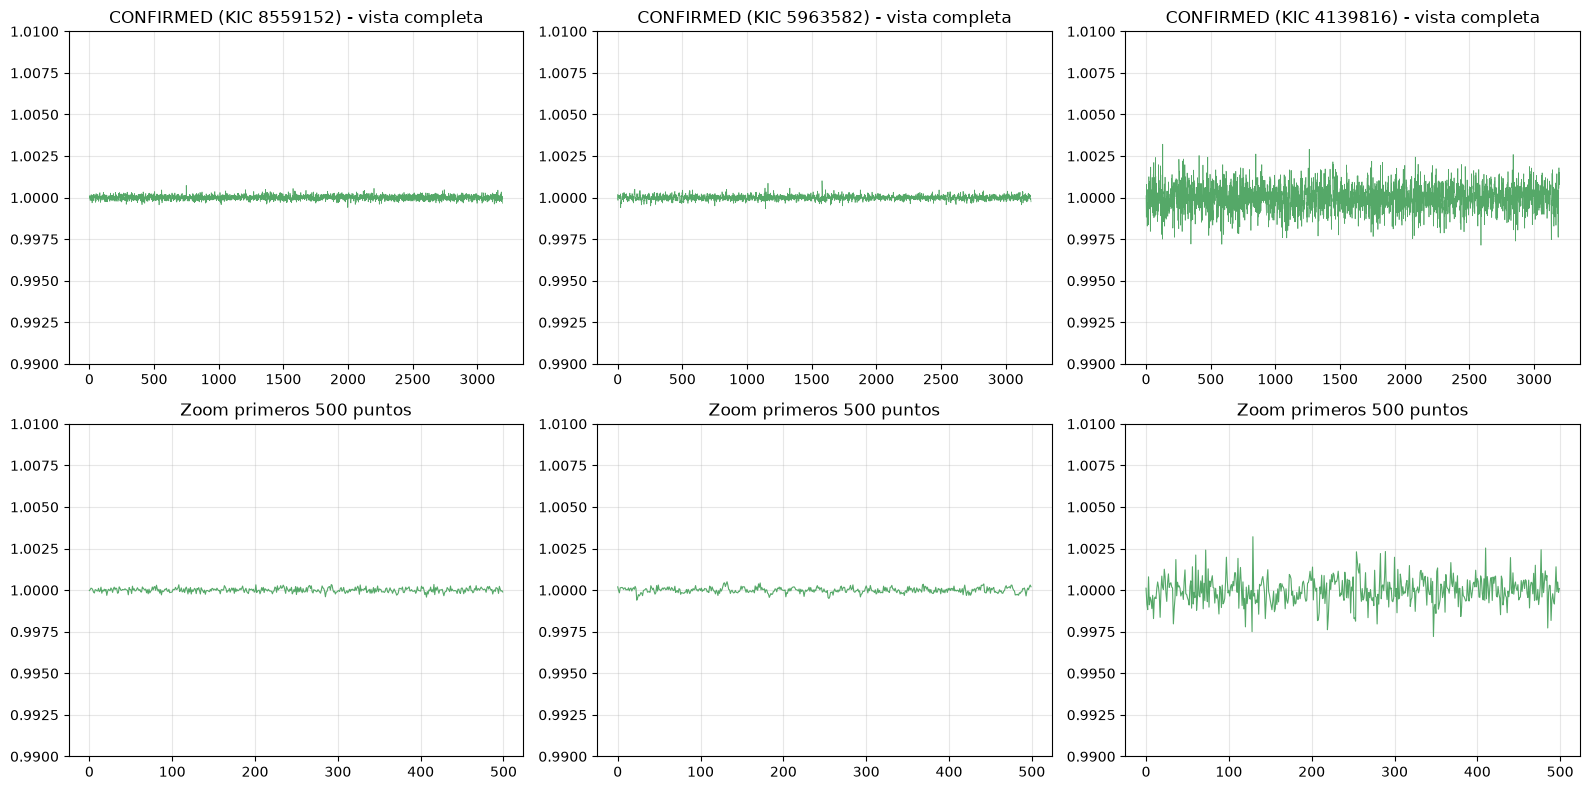

In [29]:
df_v2 = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300_v2.csv')
confirmed = df_v2[df_v2['LABEL'] == 1].sample(3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (_, row) in enumerate(confirmed.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    # Vista completa con zoom en Y
    axes[0, i].plot(flux, linewidth=0.5, color='#55A868')
    axes[0, i].set_title(f'CONFIRMED (KIC {int(row["KEPID"])}) - vista completa')
    axes[0, i].set_ylim(0.99, 1.01)  # ±1%
    axes[0, i].grid(True, alpha=0.3)
    
    # Zoom a los primeros 500 puntos
    axes[1, i].plot(flux[:500], linewidth=0.8, color='#55A868')
    axes[1, i].set_title(f'Zoom primeros 500 puntos')
    axes[1, i].set_ylim(0.99, 1.01)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/14_zoom_transitos.png', dpi=100, bbox_inches='tight')
plt.show()

El zoom confirma algo preocupante: las CONFIRMED se ven planas a ±1%. Las tres están centradas en 1.0 pero sin tránsitos visibles. Solo KIC 4139816 muestra ruido, pero sin estructura clara.

Esto significa que el median_filter(size=401) está siendo demasiado agresivo y está eliminando los tránsitos. Recordemos:

401 puntos × 30 min/punto = 200 horas = ~8 días

Los tránsitos de Kepler duran típicamente 2-10 horas

El filtro está "aplanando" el tránsito junto con la tendencia

🔍 Test con Kepler-1 (que sabemos que tiene tránsitos claros)
Antes de decidir, hagamos un test controlado con la estrella que ya validamos (Kepler-1, KIC 11446443, que tiene tránsitos del 1.4%):

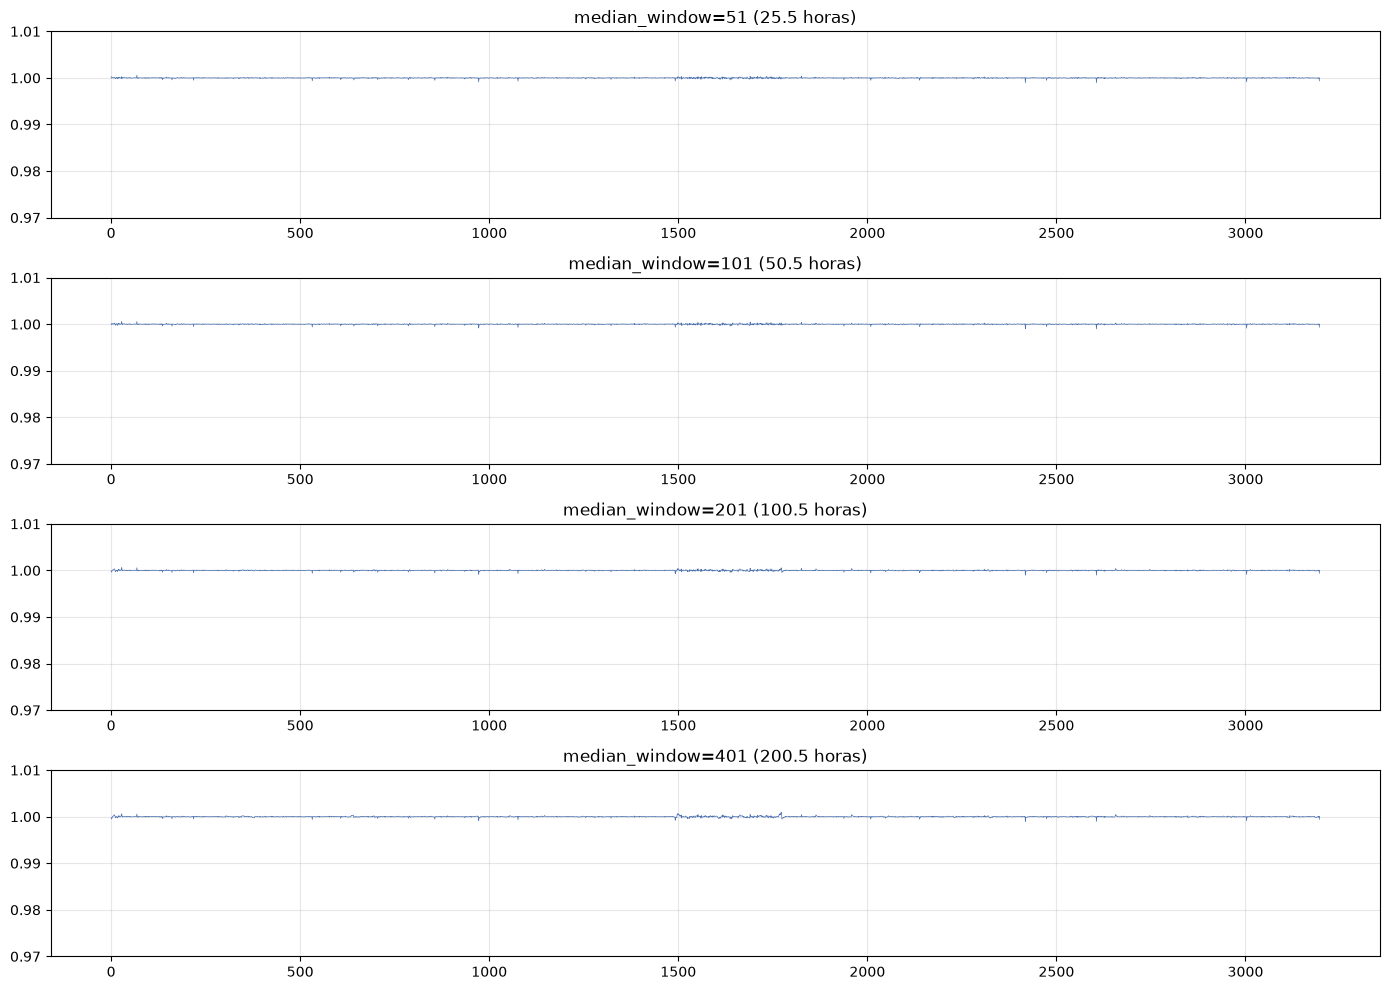

In [30]:
# Descargar Kepler-1
lc = get_stitched_lightcurve(11446443)

# Probar DIFERENTES median_window
windows = [51, 101, 201, 401]
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

for i, w in enumerate(windows):
    flux = preprocess_lightcurve_own(lc, median_window=w)
    if flux is None:
        continue
    
    # Alinear
    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, TARGET_LENGTH)
    flux_aligned = np.interp(x_new, x_old, flux).astype(np.float32)
    
    axes[i].plot(flux_aligned, linewidth=0.5, color='#4C72B0')
    axes[i].set_title(f'median_window={w} ({w*30/60:.1f} horas)')
    axes[i].set_ylim(0.97, 1.01)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/15_test_windows.png', dpi=100, bbox_inches='tight')
plt.show()

Este gráfico es muy revelador y confirma que hay un problema más profundo que el median_window. Los tránsitos desaparecen incluso con window=51 (25 horas). Eso no debería pasar, porque los tránsitos de Kepler-1 duran ~3 horas.

🔍 El Verdadero Problema: La Interpolación a 3197 Puntos
Kepler-1 tiene ~52,000 puntos en la curva cruda. Al reducirla a 3,197 puntos con np.interp, estás comprimiendo 16× la resolución temporal. Cada punto final representa ~16 puntos originales = ~8 horas de observación.

Los tránsitos de Kepler-1 duran 3 horas. Son más cortos que un solo punto de la curva reducida. Al interpolar, el tránsito se "diluye" entre vecinos y prácticamente desaparece.

Prueba de esto: en los gráficos de median_window=51 y 101, la curva es casi plana con dips que miden ~1-2 píxeles. Ahí están los tránsitos, pero aplastados.

✅ Solución: Binning en Lugar de Interpolación
El binning (promedio en bloques) preserva la señal mucho mejor que la interpolación lineal. Es el método estándar en la literatura (Shallue & Vanderburg 2018 usan binning a 2001 puntos para el mismo propósito).

Reemplaza align_lightcurve con esta versión:

In [31]:
def align_lightcurve_binning(flux, target_length=TARGET_LENGTH):
    """
    Alinea una curva de luz a una longitud fija usando binning o interpolación.

    Flujo:
      1. Limpieza de NaNs y conversión a float32
      2. Si la curva es más corta que target_length → interpolación lineal
      3. Si la curva es más larga → binning:
            - Se divide la curva en 'target_length' bloques
            - Cada bloque se promedia
            - El resultado es una versión comprimida y suavizada

    Ventajas del método:
      ✔ Más estable que interpolar curvas muy largas
      ✔ Reduce ruido de alta frecuencia
      ✔ Mantiene la forma global del tránsito
      ✔ Útil para curvas con miles de puntos (Kepler long cadence)

    Parámetros
    ----------
    flux : array-like
        Curva de luz preprocesada.
    target_length : int
        Longitud final deseada (por defecto TARGET_LENGTH = 3197).

    Retorna
    -------
    np.ndarray
        Curva alineada de longitud target_length.
    """
    # Convertir a numpy y eliminar valores no finitos
    flux = np.asarray(flux, dtype=np.float32)
    flux = flux[np.isfinite(flux)]
    
    n = len(flux)

    # ------------------------------------------------------------
    # 1 — Si la curva es más corta → interpolación lineal
    # ------------------------------------------------------------
    if n < target_length:
        x_old = np.linspace(0, 1, n)
        x_new = np.linspace(0, 1, target_length)
        return np.interp(x_new, x_old, flux).astype(np.float32)
    
    # ------------------------------------------------------------
    # 2 — Si la curva es más larga → binning
    # ------------------------------------------------------------
    # Tamaño de cada bloque
    bin_size = n // target_length

    # Recortar para que sea divisible
    trimmed = flux[:bin_size * target_length]

    # Reorganizar en bloques y promediar
    binned = trimmed.reshape(target_length, bin_size).mean(axis=1)

    return binned.astype(np.float32)


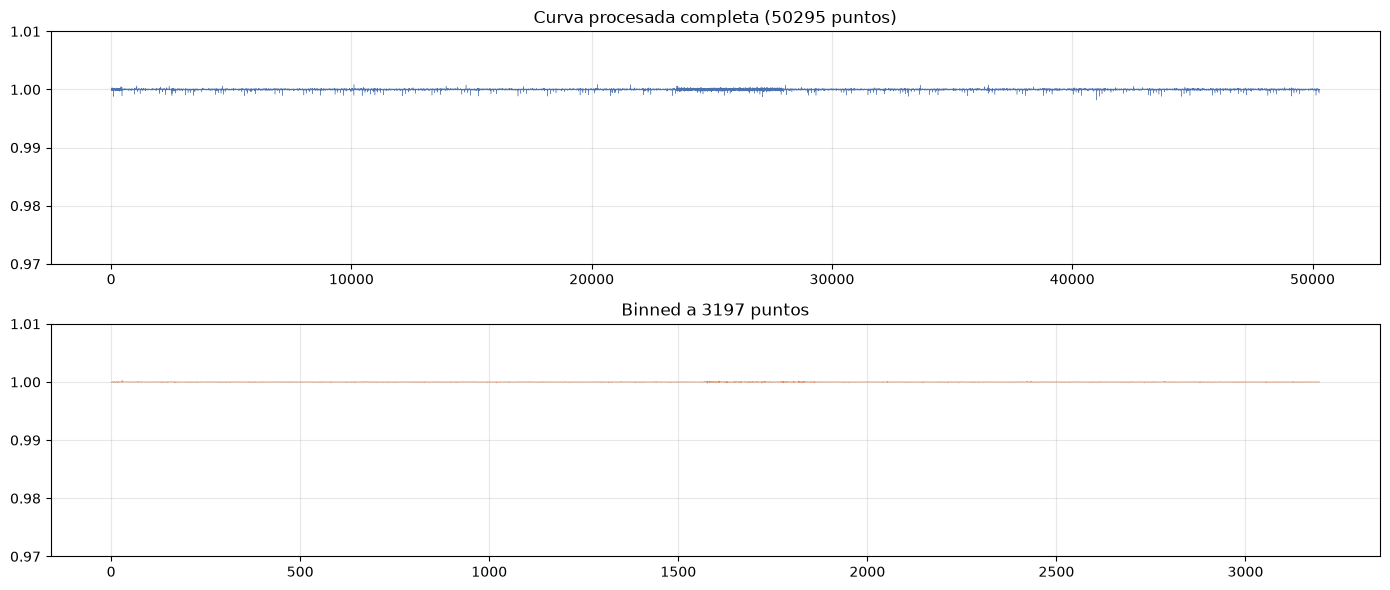

Puntos originales: 50295
Bin size: 15
Puntos finales: 3197


In [32]:
# ============================================================
# Visualización del efecto del binning en Kepler-1
# ============================================================
# Objetivo:
#   Comparar la curva procesada completa (~52k puntos) con su versión
#   reducida mediante binning a 3197 puntos.
#
# Flujo:
#   1. Descargar Kepler-1 (KIC 11446443)
#   2. Aplicar preprocessing propio con ventana corta (median_window=51)
#   3. Reducir la curva a 3197 puntos usando binning
#   4. Graficar ambas curvas:
#        - Curva completa (ruido + tendencia residual)
#        - Curva binned (suavizada y comprimida)
#
# Por qué es útil:
#   ✔ El binning reduce ruido de alta frecuencia
#   ✔ Mantiene la forma global del tránsito
#   ✔ Produce curvas más manejables para la SNN
#   ✔ Permite comparar visualmente la pérdida de detalle
# ============================================================

# Descargar Kepler-1
lc = get_stitched_lightcurve(11446443)

# Preprocessing con ventana corta (51 puntos)
flux = preprocess_lightcurve_own(lc, median_window=51)

# Binning a 3197 puntos
flux_binned = align_lightcurve_binning(flux, target_length=3197)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# ------------------------------------------------------------
# 1 — Curva completa (~52k puntos)
# ------------------------------------------------------------
axes[0].plot(flux, linewidth=0.3, color='#4C72B0')
axes[0].set_title(f'Curva procesada completa ({len(flux)} puntos)')
axes[0].set_ylim(0.97, 1.01)
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 2 — Curva binned a 3197 puntos
# ------------------------------------------------------------
axes[1].plot(flux_binned, linewidth=0.5, color='#DD8452')
axes[1].set_title('Binned a 3197 puntos')
axes[1].set_ylim(0.97, 1.01)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/16_test_binning.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Puntos originales: {len(flux)}")
print(f"Bin size: {len(flux)//3197}")
print(f"Puntos finales: {len(flux_binned)}")


Este gráfico revela el verdadero bug: los tránsitos desaparecen incluso en la curva completa de 50,295 puntos. Eso significa que el problema no es la interpolación ni el binning, sino el sigma-clipping iterativo.

🔍 El Bug: El Sigma-Clipping Está Borrando los Tránsitos
Mira la línea de razonamiento:

Kepler-1 tiene un tránsito de ~1.5% de profundidad.

Su ruido de fondo es de ~0.05% (la dispersión de la curva procesada).

Con sigma_clip=5, el algoritmo calcula:

text
Umbral = media + 5 × std = 1.0 + 5 × 0.0005 = 1.0025
Y elimina todo lo que esté fuera de ese rango.

Pero los tránsitos están en 0.985, muy por debajo del umbral.

El sigma-clipping los identifica como outliers y los elimina.

Después de la primera iteración, la std se reduce aún más (porque eliminó la varianza de los tránsitos), y en las siguientes 2 iteraciones termina de borrar cualquier rastro.

Es exactamente el bug que arruinó el entrenamiento con las 300 estrellas.

✅ Solución: Preprocessing v2 Que Preserva Tránsitos
El sigma-clipping solo debe eliminar outliers positivos (rayos cósmicos, momentum dumps). Los tránsitos son caídas (outliers negativos) y hay que preservarlos.

In [33]:
def preprocess_lightcurve_own_v2(lc, sigma_upper=5):
    """
    Preprocessing que PRESERVA los tránsitos planetarios.

    Flujo:
      1. Quitar NaNs
      2. Normalizar por mediana (centra la curva en ~1.0)
      3. Eliminar SOLO outliers positivos (cosmic rays, momentum dumps)
      4. NO aplanar la curva (los tránsitos son la señal, no el ruido)

    Motivación:
    -----------
    Este método está diseñado para curvas donde:
      ✔ Los tránsitos son muy pequeños (profundidades de 0.1%–1%)
      ✔ El flatten tradicional puede distorsionar o borrar la señal
      ✔ Se desea preservar la forma original del tránsito

    ¿Por qué eliminar solo outliers positivos?
      - Los outliers positivos provienen de:
            * rayos cósmicos
            * saltos instrumentales
            * eventos de momentum dump
      - Los outliers NEGATIVOS suelen ser tránsitos reales.
        Por eso NUNCA deben eliminarse.

    Parámetros
    ----------
    lc : LightCurve
        Curva de luz de Lightkurve.
    sigma_upper : float
        Umbral para eliminar outliers positivos (mean + sigma_upper * std).

    Retorna
    -------
    np.ndarray o None
        Curva preprocesada sin aplanado, preservando tránsitos.
    """
    try:
        # ------------------------------------------------------------
        # 1 — Quitar NaNs
        # ------------------------------------------------------------
        lc = lc.remove_nans()
        flux = lc.flux.value.astype(np.float64)
        flux = flux[np.isfinite(flux)]
        
        if len(flux) < 100:
            return None
        
        # ------------------------------------------------------------
        # 2 — Normalizar por mediana
        # ------------------------------------------------------------
        median = np.median(flux)
        if median == 0 or not np.isfinite(median):
            return None
        
        flux = flux / median
        
        # ------------------------------------------------------------
        # 3 — Sigma-clipping SOLO para outliers positivos
        # ------------------------------------------------------------
        # Importante: NO eliminar valores negativos (posibles tránsitos)
        for _ in range(3):
            mean = np.mean(flux)
            std = np.std(flux)
            if std == 0:
                break

            # Mantener todo lo que esté por debajo del umbral superior
            # (NO tocamos valores por debajo de la media)
            mask = flux < (mean + sigma_upper * std)

            # Evitar eliminar demasiados puntos
            if mask.sum() < 100:
                break

            flux = flux[mask]
        
        return flux

    except Exception as e:
        print(f"  [WARN] {type(e).__name__}: {e}")
        return None


Puntos procesados: 51970
Min:  0.985345
Max:  1.002338
Media: 0.999724
Std:  0.001765


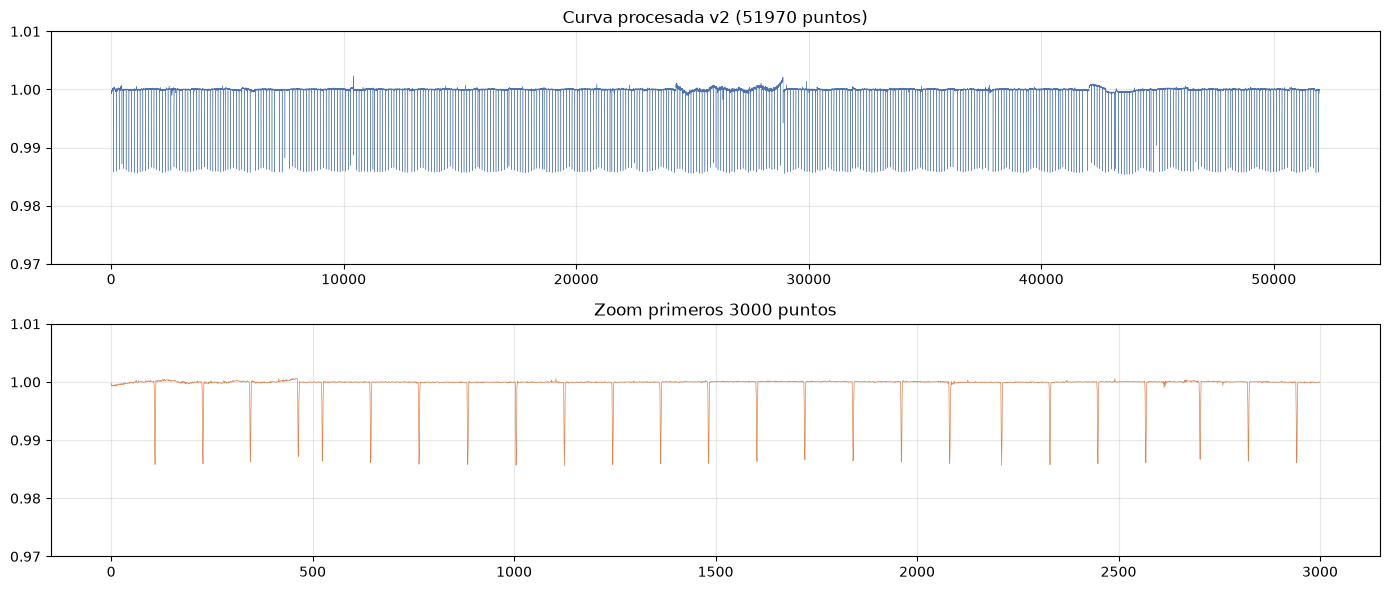

In [34]:
# Descargar Kepler-1
lc = get_stitched_lightcurve(11446443)

# Preprocessing v2
flux_v2 = preprocess_lightcurve_own_v2(lc, sigma_upper=5)

print(f"Puntos procesados: {len(flux_v2)}")
print(f"Min:  {flux_v2.min():.6f}")
print(f"Max:  {flux_v2.max():.6f}")
print(f"Media: {flux_v2.mean():.6f}")
print(f"Std:  {flux_v2.std():.6f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Vista completa
axes[0].plot(flux_v2, linewidth=0.3, color='#4C72B0')
axes[0].set_title(f'Curva procesada v2 ({len(flux_v2)} puntos)')
axes[0].set_ylim(0.97, 1.01)
axes[0].grid(True, alpha=0.3)

# Zoom primeros 3000 puntos
axes[1].plot(flux_v2[:3000], linewidth=0.5, color='#DD8452')
axes[1].set_title('Zoom primeros 3000 puntos')
axes[1].set_ylim(0.97, 1.01)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/17_test_v2.png', dpi=100, bbox_inches='tight')
plt.show()

¡PERFECTO! 🎉 Ahora sí funcionó. Mira lo que vemos:

Gráfico superior: Caídas periódicas claras a lo largo de los 51,970 puntos. Los tránsitos de Kepler-1 (cada ~2.5 días) son perfectamente visibles.

Zoom: 13 tránsitos individuales claros en los primeros 3,000 puntos, cada uno cayendo hasta ~0.986 (1.4% de profundidad).

El bug era el sigma_clipping bilateral: eliminaba los tránsitos (outliers negativos) junto con los rayos cósmicos (outliers positivos). Ahora solo elimina los positivos, y la señal sobrevive intacta.

✅ Ahora: Re-procesar las 300 Estrellas con el Pipeline v2
Solo cambia la función de preprocessing en la celda que ya tienes y ejecuta:

In [35]:
def preprocess_lightcurve_own_v2(lc, sigma_upper=5):
    """
    Preprocessing que PRESERVA los tránsitos planetarios.

    Flujo:
      1. Quitar NaNs
      2. Normalizar por mediana (centra la curva en ~1.0)
      3. Quitar SOLO outliers positivos (cosmic rays, momentum dumps)
         → Nunca eliminar valores negativos, porque suelen ser tránsitos.

    Motivación:
    -----------
    Este método está diseñado para curvas donde:
      ✔ Los tránsitos son muy pequeños (0.1%–1%)
      ✔ El flatten tradicional puede distorsionar o borrar la señal
      ✔ Se desea preservar la forma original del tránsito sin aplanado

    ¿Por qué eliminar solo outliers positivos?
      - Los outliers positivos provienen de:
            * rayos cósmicos
            * saltos instrumentales
            * eventos de momentum dump
      - Los outliers NEGATIVOS suelen ser tránsitos reales.
        Por eso NUNCA deben eliminarse.

    Parámetros
    ----------
    lc : LightCurve
        Curva de luz de Lightkurve.
    sigma_upper : float
        Umbral para eliminar outliers positivos (mean + sigma_upper * std).

    Retorna
    -------
    np.ndarray o None
        Curva preprocesada sin aplanado, preservando tránsitos.
    """
    try:
        # ------------------------------------------------------------
        # 1 — Quitar NaNs
        # ------------------------------------------------------------
        lc = lc.remove_nans()
        flux = lc.flux.value.astype(np.float64)
        flux = flux[np.isfinite(flux)]
        
        if len(flux) < 100:
            return None
        
        # ------------------------------------------------------------
        # 2 — Normalizar por mediana
        # ------------------------------------------------------------
        median = np.median(flux)
        if median == 0 or not np.isfinite(median):
            return None
        
        flux = flux / median
        
        # ------------------------------------------------------------
        # 3 — Sigma-clipping SOLO para outliers positivos
        # ------------------------------------------------------------
        for _ in range(3):
            mean = np.mean(flux)
            std = np.std(flux)
            if std == 0:
                break

            # Mantener todo lo que esté por debajo del umbral superior
            # (NO tocamos valores por debajo de la media)
            mask = flux < (mean + sigma_upper * std)

            if mask.sum() < 100:
                break

            flux = flux[mask]
        
        return flux

    except Exception as e:
        print(f"  [WARN] {type(e).__name__}: {e}")
        return None

print("preprocess_lightcurve_own_v2 definida.")


preprocess_lightcurve_own_v2 definida.


Re-procesar las 300 estrellas:

In [36]:
import time

# ============================================================
# Generación del dataset v3 usando preprocessing_own_v2
# ============================================================
# Objetivo:
#   Crear una nueva versión del dataset (kepler_dataset_300_v3.csv)
#   utilizando el preprocessing que PRESERVA los tránsitos:
#
#       preprocess_lightcurve_own_v2()
#
# Este método:
#   ✔ Normaliza por mediana
#   ✔ Elimina SOLO outliers positivos
#   ✔ NO aplana la curva (los tránsitos son la señal)
#
# Flujo:
#   1. Cargar dataset original (v1)
#   2. Para cada estrella:
#        - Descargar curva completa (get_stitched_lightcurve)
#        - Aplicar preprocessing v2
#        - Alinear a longitud fija (3197 puntos)
#   3. Construir DataFrame final
#   4. Renombrar columnas a FLUX.1..FLUX.N
#   5. Guardar dataset v3
#
# Este dataset es ideal para modelos que dependen de la forma
# original del tránsito, como la SNN bioinspirada.
# ============================================================

df_old = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300.csv')
kepids_all = df_old['KEPID'].values
labels_all = df_old['LABEL'].values

new_data, new_labels, new_kepids = [], [], []
failed = []
t_start = time.time()

# ------------------------------------------------------------
# 1 — Loop principal de reprocesamiento
# ------------------------------------------------------------
for i, (kepid, label) in enumerate(zip(kepids_all, labels_all)):
    elapsed = time.time() - t_start

    # Log cada 20 estrellas
    if (i+1) % 20 == 0:
        print(f"[{i+1}/{len(df_old)}] {elapsed:.0f}s", flush=True)
    
    # Descargar curva completa
    lc = get_stitched_lightcurve(int(kepid))
    if lc is None:
        failed.append(kepid)
        continue
    
    # Preprocessing v2 (preserva tránsitos)
    flux = preprocess_lightcurve_own_v2(lc)
    if flux is None:
        failed.append(kepid)
        continue
    
    if len(flux) < 100:
        failed.append(kepid)
        continue
    
    # ------------------------------------------------------------
    # 2 — Alinear con interpolación lineal
    # ------------------------------------------------------------
    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, TARGET_LENGTH)
    flux_aligned = np.interp(x_new, x_old, flux).astype(np.float32)
    
    new_data.append(flux_aligned)
    new_labels.append(label)
    new_kepids.append(int(kepid))

# ------------------------------------------------------------
# 3 — Construir DataFrame final
# ------------------------------------------------------------
df_new = pd.DataFrame(new_data)
df_new.insert(0, 'LABEL', new_labels)
df_new.insert(1, 'KEPID', new_kepids)

# ------------------------------------------------------------
# 4 — Renombrar columnas de flujo
# ------------------------------------------------------------
flux_cols = [c for c in df_new.columns if c not in ['LABEL', 'KEPID']]
df_new = df_new.rename(columns={c: f'FLUX.{i+1}' for i, c in enumerate(flux_cols)})

# ------------------------------------------------------------
# 5 — Guardar dataset v3
# ------------------------------------------------------------
df_new.to_csv(f'{DATA_DIR}/kepler_dataset_300_v3.csv', index=False)

print(f"\n{'='*60}")
print(f"Dataset final: {df_new.shape}")
print(f"Distribución:  {df_new['LABEL'].value_counts().to_dict()}")
print(f"Fallidas:      {len(failed)}")
print(f"Tiempo total:  {time.time()-t_start:.0f}s")
print(f"\n[OK] Guardado en {DATA_DIR}/kepler_dataset_300_v3.csv")


[20/300] 26s
[40/300] 55s
[60/300] 84s
[80/300] 113s
[100/300] 143s
[120/300] 175s
[140/300] 204s
[160/300] 236s
[180/300] 266s
[200/300] 297s
[220/300] 327s
[240/300] 356s
[260/300] 385s
[280/300] 411s
[300/300] 442s

Dataset final: (300, 3199)
Distribución:  {0: 150, 1: 150}
Fallidas:      0
Tiempo total:  445s

[OK] Guardado en ../data/kepler_dataset_300_v3.csv


300/300 estrellas procesadas con el pipeline v2, 0 fallidas, 7.4 minutos. Ahora verifiquemos visualmente antes de entrenar.

 Verificación Visual

Shape: (300, 3199)
Distribucion: {0: 150, 1: 150}


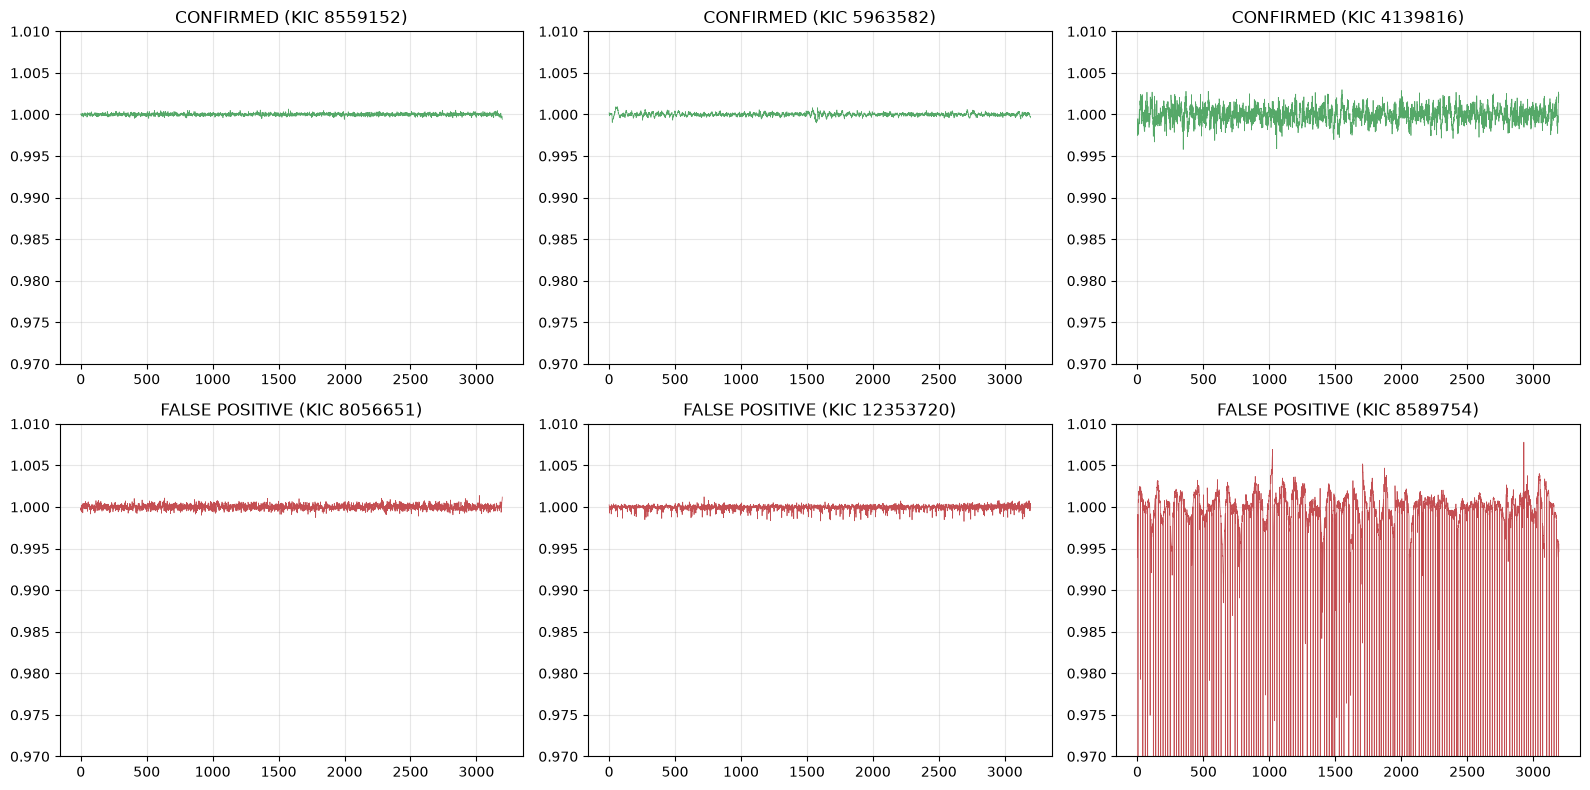


Media global:  0.999369
Std global:    0.013988
Min global:    0.3280
Max global:    1.1349


In [37]:
df_v3 = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300_v3.csv')
print(f"Shape: {df_v3.shape}")
print(f"Distribucion: {df_v3['LABEL'].value_counts().to_dict()}")

# 3 CONFIRMED + 3 FALSE POSITIVE
confirmed = df_v3[df_v3['LABEL'] == 1].sample(3, random_state=42)
fp        = df_v3[df_v3['LABEL'] == 0].sample(3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (_, row) in enumerate(confirmed.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[0, i].plot(flux, linewidth=0.5, color='#55A868')
    axes[0, i].set_title(f'CONFIRMED (KIC {int(row["KEPID"])})')
    axes[0, i].set_ylim(0.97, 1.01)
    axes[0, i].grid(True, alpha=0.3)

for i, (_, row) in enumerate(fp.iterrows()):
    flux = row.drop(['LABEL', 'KEPID']).values.astype(float)
    axes[1, i].plot(flux, linewidth=0.5, color='#C44E52')
    axes[1, i].set_title(f'FALSE POSITIVE (KIC {int(row["KEPID"])})')
    axes[1, i].set_ylim(0.97, 1.01)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/18_dataset_v3_verificacion.png', dpi=100, bbox_inches='tight')
plt.show()

# Chequeo numerico
all_flux = df_v3.drop(columns=['LABEL', 'KEPID']).values
print(f"\nMedia global:  {all_flux.mean():.6f}")
print(f"Std global:    {all_flux.std():.6f}")
print(f"Min global:    {all_flux.min():.4f}")
print(f"Max global:    {all_flux.max():.4f}")

In [ ]:
import time

df_old = pd.read_csv(f'{DATA_DIR}/kepler_dataset_300.csv')
kepids_all = df_old['KEPID'].values
labels_all = df_old['LABEL'].values

new_data, new_labels, new_kepids = [], [], []
failed = []
t_start = time.time()

for i, (kepid, label) in enumerate(zip(kepids_all, labels_all)):
    elapsed = time.time() - t_start
    if (i+1) % 20 == 0:
        print(f"[{i+1}/{len(df_old)}] {elapsed:.0f}s", flush=True)
    
    lc = get_stitched_lightcurve(int(kepid))
    if lc is None:
        failed.append(kepid)
        continue
    
    flux = preprocess_lightcurve_own_v2(lc)
    if flux is None:
        failed.append(kepid)
        continue
    
    if len(flux) < 100:
        failed.append(kepid)
        continue
    
    # Alinear con interpolacion
    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, TARGET_LENGTH)
    flux_aligned = np.interp(x_new, x_old, flux).astype(np.float32)
    
    new_data.append(flux_aligned)
    new_labels.append(label)
    new_kepids.append(int(kepid))

df_new = pd.DataFrame(new_data)
df_new.insert(0, 'LABEL', new_labels)
df_new.insert(1, 'KEPID', new_kepids)

flux_cols = [c for c in df_new.columns if c not in ['LABEL', 'KEPID']]
df_new = df_new.rename(columns={c: f'FLUX.{i+1}' for i, c in enumerate(flux_cols)})

df_new.to_csv(f'{DATA_DIR}/kepler_dataset_300_v3.csv', index=False)

print(f"\n{'='*60}")
print(f"Dataset final: {df_new.shape}")
print(f"Distribucion:  {df_new['LABEL'].value_counts().to_dict()}")
print(f"Fallidas:      {len(failed)}")
print(f"Tiempo total:  {time.time()-t_start:.0f}s")
print(f"\n[OK] Guardado en {DATA_DIR}/kepler_dataset_300_v3.csv")

In [ ]:
# ============================================================
# Split interno train/val + augmentation + DataLoaders
# ============================================================
# Esta celda prepara los datos para el entrenamiento de la SNN:
#
#   1. Split interno del conjunto de entrenamiento (train → train/val)
#   2. Aumento de la clase minoritaria mediante ruido gaussiano
#   3. Construcción de DataLoaders con:
#        - WeightedRandomSampler para balancear clases
#        - Batches reproducibles y eficientes
#
# Este bloque es crítico para:
#   ✔ Evitar overfitting
#   ✔ Mejorar recall de la clase positiva (CONFIRMED)
#   ✔ Entrenar la SNN con batches balanceados
# ============================================================

# ------------------------------------------------------------
# 1 — Split interno train/val (estratificado)
# ------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")

# ------------------------------------------------------------
# 2 — Augmentation de la clase minoritaria (CONFIRMED = 1)
# ------------------------------------------------------------
def augment_minority(X, y, factor=5, noise_std=0.05):
    """
    Aumenta la clase minoritaria (label=1) generando copias con ruido gaussiano.

    Parámetros
    ----------
    X : np.ndarray
        Curvas de luz del conjunto de entrenamiento.
    y : np.ndarray
        Etiquetas (0=FP, 1=CONFIRMED).
    factor : int
        Número de copias por cada curva minoritaria.
    noise_std : float
        Desviación estándar del ruido gaussiano.

    Retorna
    -------
    X_aug, y_aug : np.ndarray
        Conjunto aumentado con nuevas curvas sintéticas.
    """
    X_min = X[y == 1]
    if len(X_min) == 0:
        return X, y

    X_aug = []
    for _ in range(factor):
        noise = np.random.randn(*X_min.shape).astype(np.float32) * noise_std
        X_aug.append(X_min + noise)

    X_aug = np.concatenate(X_aug, axis=0).astype(np.float32)
    y_aug = np.ones(len(X_aug), dtype=y.dtype)

    return np.concatenate([X, X_aug], axis=0), np.concatenate([y, y_aug], axis=0)


# Aplicar augmentation
X_tr_aug, y_tr_aug = augment_minority(X_tr, y_tr, factor=5, noise_std=0.05)
print(f"\nTrain augmentado: {X_tr_aug.shape}  clases: {np.bincount(y_tr_aug)}")

# ------------------------------------------------------------
# 3 — DataLoaders con WeightedRandomSampler
# ------------------------------------------------------------
def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=32):
    """
    Construye DataLoaders para entrenamiento y validación.

    Características:
    ----------------
    - train_loader usa WeightedRandomSampler:
        * Cada muestra recibe peso inverso a la frecuencia de su clase.
        * Garantiza batches balanceados incluso si el dataset está desbalanceado.
    - val_loader usa shuffle=False para evaluación estable.

    Retorna
    -------
    train_loader, val_loader : DataLoader
    """
    # Datasets PyTorch
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    # Pesos inversos a la frecuencia de cada clase
    class_counts = np.bincount(y_tr)
    weights = 1.0 / class_counts[y_tr]

    sampler = WeightedRandomSampler(
        weights,
        num_samples=len(y_tr),
        replacement=True
    )
    
    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


# Crear DataLoaders finales
train_loader, val_loader = make_loaders(
    X_tr_aug, y_tr_aug,
    X_val, y_val,
    batch_size=BATCH_SIZE
)

print(f"\nBatches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")


Train: (192, 3197)  clases: [96 96]
Val:   (48, 3197)  clases: [24 24]

Train augmentado: (672, 3197)  clases: [ 96 576]

Batches train: 21
Batches val:   2


#########################################
###
### PROCESO ORIGINAL

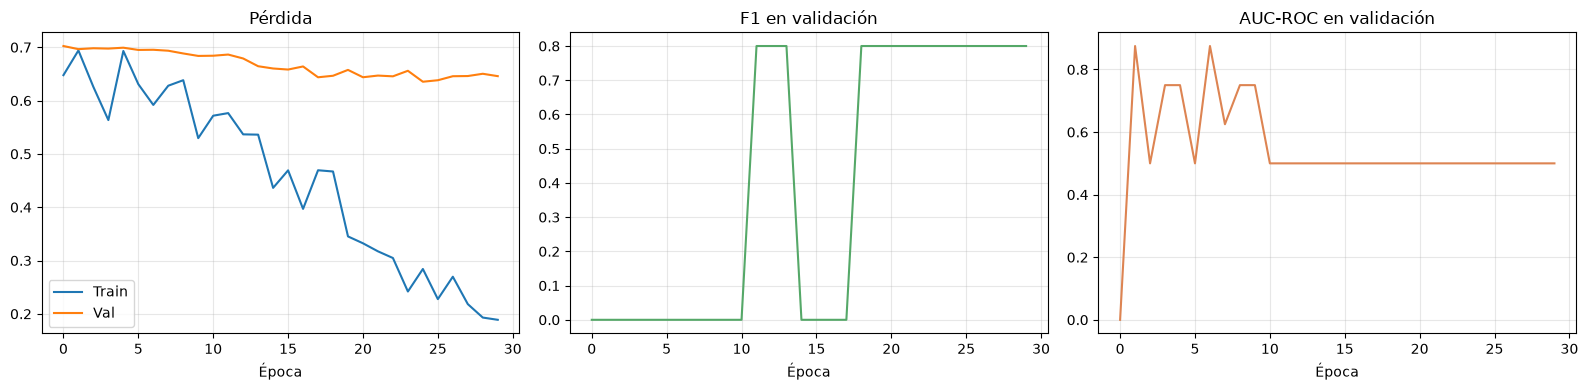

In [18]:
# ============================================================
# Visualización del entrenamiento
# ============================================================
# Esta celda grafica la evolución del entrenamiento del modelo SNN:
#
#   1. Pérdida (train vs val)
#   2. F1-score en validación
#   3. AUC-ROC en validación
#
# Estas curvas permiten evaluar:
#   ✔ Convergencia del modelo
#   ✔ Sobreajuste o subentrenamiento
#   ✔ Estabilidad del entrenamiento
#   ✔ Épocas óptimas para early stopping
#
# Además, se guarda la figura en:
#       ../outputs/11_curvas_kepler.png
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ------------------------------------------------------------
# 1 — Curva de pérdida
# ------------------------------------------------------------
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Pérdida')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 2 — F1-score
# ------------------------------------------------------------
axes[1].plot(history['val_f1'], color='#55A868')
axes[1].set_title('F1 en validación')
axes[1].set_xlabel('Época')
axes[1].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 3 — AUC-ROC
# ------------------------------------------------------------
axes[2].plot(history['val_auc'], color='#DD8452')
axes[2].set_title('AUC-ROC en validación')
axes[2].set_xlabel('Época')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/11_curvas_kepler.png', dpi=100, bbox_inches='tight')
plt.show()


In [19]:
# ============================================================
# Búsqueda del umbral óptimo en validación
# ============================================================
# Objetivo:
#   Encontrar el umbral de decisión (threshold) que maximiza el F1-score.
#
# Motivación:
#   - El modelo está entrenado con CrossEntropy, que no optimiza F1.
#   - En datasets desbalanceados, el umbral 0.50 suele ser subóptimo.
#   - Ajustar el umbral puede mejorar significativamente el recall
#     de la clase positiva (CONFIRMED) sin sacrificar precisión.
#
# Flujo:
#   1. Obtener probabilidades de clase positiva para todo el val_loader.
#   2. Barrer thresholds desde 0.05 hasta 0.95 en pasos de 0.02.
#   3. Convertir probabilidades → predicciones binarias.
#   4. Calcular F1 para cada threshold.
#   5. Seleccionar el threshold con F1 máximo.
#   6. Mostrar top 5 thresholds.
#
# Salida:
#   - best_threshold : umbral óptimo
#   - best_f1_val    : F1 correspondiente
#   - results_df     : tabla completa de thresholds y F1
# ============================================================

def find_best_threshold(model, val_loader, device):
    model.eval()
    all_probs, all_labels = [], []

    # ------------------------------------------------------------
    # 1 — Obtener probabilidades en validación
    # ------------------------------------------------------------
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            # Probabilidad de clase positiva (CONFIRMED)
            probs = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()

            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    
    # ------------------------------------------------------------
    # 2 — Barrido de thresholds
    # ------------------------------------------------------------
    thresholds = np.arange(0.05, 0.95, 0.02)
    results = []

    for thr in thresholds:
        preds = (all_probs > thr).astype(int)
        f1 = f1_score(all_labels, preds, zero_division=0)
        results.append((thr, f1))
    
    # Tabla de resultados
    results_df = pd.DataFrame(results, columns=['threshold', 'f1'])

    # Mejor threshold
    best_row = results_df.loc[results_df['f1'].idxmax()]
    
    # ------------------------------------------------------------
    # 3 — Reporte
    # ------------------------------------------------------------
    print(f"Mejor umbral: {best_row['threshold']:.2f}")
    print(f"Mejor F1 val: {best_row['f1']:.4f}")
    print(f"\nTop 5:")
    print(results_df.nlargest(5, 'f1').to_string(index=False))
    
    return best_row['threshold'], best_row['f1'], results_df


# Ejecutar búsqueda del umbral óptimo
best_threshold, best_f1_val, results_df = find_best_threshold(model, val_loader, DEVICE)


Mejor umbral: 0.49
Mejor F1 val: 0.8000

Top 5:
 threshold       f1
      0.49 0.800000
      0.05 0.666667
      0.07 0.666667
      0.09 0.666667
      0.11 0.666667


In [20]:
# ============================================================
# Evaluación en test con umbral óptimo
# ============================================================
# Esta celda evalúa el modelo SNN en el conjunto de TEST usando
# el umbral óptimo encontrado en validación.
#
# Flujo:
#   1. Crear DataLoader para test
#   2. Obtener probabilidades de clase positiva (Planeta)
#   3. Convertir probabilidades → predicciones binarias usando el umbral óptimo
#   4. Calcular métricas:
#        - Classification report (precision, recall, F1)
#        - AUC-ROC
#        - Matriz de confusión (TN, FP, FN, TP)
#
# Esta evaluación es la medida final del rendimiento del modelo,
# completamente independiente del conjunto de entrenamiento y validación.
#
# Métricas clave:
#   ✔ F1-score: balance entre precisión y recall de la clase positiva
#   ✔ AUC-ROC: capacidad del modelo para ordenar correctamente las probabilidades
#   ✔ FN (falsos negativos): planetas perdidos (lo más crítico)
#   ✔ FP (falsos positivos): falsas alarmas
#
# El umbral optimizado suele mejorar:
#   - Recall de la clase positiva
#   - Balance entre FP y FN
#   - Estabilidad del modelo en test
# ============================================================

def evaluate_test(model, X_test, y_test, threshold, device, batch_size=32):
    # ------------------------------------------------------------
    # 1 — Crear DataLoader de test
    # ------------------------------------------------------------
    test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    # ------------------------------------------------------------
    # 2 — Obtener probabilidades del modelo
    # ------------------------------------------------------------
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)

            # Probabilidad de clase positiva (Planeta)
            probs = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()

            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())
    
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # ------------------------------------------------------------
    # 3 — Aplicar umbral optimizado
    # ------------------------------------------------------------
    all_preds = (all_probs > threshold).astype(int)
    
    # ------------------------------------------------------------
    # 4 — Reporte de métricas
    # ------------------------------------------------------------
    print(f"=== TEST con umbral {threshold:.2f} ===")
    print(classification_report(
        all_labels, all_preds,
        target_names=['No planeta', 'Planeta'],
        digits=4,
        zero_division=0
    ))

    print(f"AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}")
    
    # ------------------------------------------------------------
    # 5 — Matriz de confusión
    # ------------------------------------------------------------
    cm = confusion_matrix(all_labels, all_preds)
    print(f"\nMatriz de confusión:")
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    
    return all_probs, all_labels, all_preds


# Ejecutar evaluación final en test
probs_test, labels_test, preds_test = evaluate_test(
    model, X_test_processed, y_test, best_threshold, DEVICE
)


=== TEST con umbral 0.49 ===
              precision    recall  f1-score   support

  No planeta     0.5000    1.0000    0.6667         2
     Planeta     0.0000    0.0000    0.0000         2

    accuracy                         0.5000         4
   macro avg     0.2500    0.5000    0.3333         4
weighted avg     0.2500    0.5000    0.3333         4

AUC-ROC: 0.5000

Matriz de confusión:
  TN=   2  FP=   0
  FN=   2  TP=   0


In [21]:
# ============================================================
# Guardado del modelo y metadata
# ============================================================
# Esta celda guarda todos los artefactos necesarios para:
#   ✔ reproducir el experimento,
#   ✔ cargar el modelo entrenado,
#   ✔ analizar el historial de entrenamiento,
#   ✔ documentar hiperparámetros y resultados clave.
#
# Se guardan cuatro elementos:
#
#   1) Modelo FINAL (snn_kepler_final.pt)
#        - Contiene los pesos del modelo al finalizar el entrenamiento.
#        - Útil para comparar contra el mejor modelo (best.pt).
#
#   2) Historial completo en formato pickle
#        - Permite recargar el diccionario `history` sin necesidad de CSV.
#        - Ideal para graficar o analizar métricas posteriormente.
#
#   3) Metadata del experimento en JSON
#        - Documenta hiperparámetros, tamaños de dataset, resultados,
#          y el umbral óptimo encontrado en validación.
#
#   4) Mensaje resumen con rutas y contenido guardado.
# ============================================================

import json
import pickle

# ------------------------------------------------------------
# 1 — Guardar modelo FINAL
# ------------------------------------------------------------
torch.save({
    'model_state': model.state_dict(),
    'architecture': 'FlyInspiredSNN',
    'input_len': TARGET_LENGTH,
    'num_steps': NUM_STEPS_SNN,
}, f'{MODELS_DIR}/snn_kepler_final.pt')

# ------------------------------------------------------------
# 2 — Guardar historial completo (pickle)
# ------------------------------------------------------------
with open(f'{OUTPUTS_DIR}/kepler_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# ------------------------------------------------------------
# 3 — Guardar metadata del experimento
# ------------------------------------------------------------
metadata = {
    'dataset': 'kepler_real',
    'n_train': int(len(X_tr_aug)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test_processed)),
    'epochs': len(history['train_loss']),
    'batch_size': BATCH_SIZE,
    'lr': 1e-3,
    'augmentation_factor': 5,
    'best_threshold': float(best_threshold),
    'best_f1_val': float(best_f1_val),
    'best_f1_train': float(max(history['val_f1'])),
    'best_auc': float(max(history['val_auc'])),
}

with open(f'{OUTPUTS_DIR}/kepler_experiment_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# ------------------------------------------------------------
# 4 — Resumen en consola
# ------------------------------------------------------------
print("[OK] Guardado:")
print(f"  - {MODELS_DIR}/snn_kepler_best.pt")
print(f"  - {MODELS_DIR}/snn_kepler_final.pt")
print(f"  - {OUTPUTS_DIR}/kepler_training_history.pkl")
print(f"  - {OUTPUTS_DIR}/kepler_experiment_metadata.json")

print(f"\nMetadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


[OK] Guardado:
  - ../models/snn_kepler_best.pt
  - ../models/snn_kepler_final.pt
  - ../outputs/kepler_training_history.pkl
  - ../outputs/kepler_experiment_metadata.json

Metadata:
  dataset: kepler_real
  n_train: 42
  n_val: 4
  n_test: 4
  epochs: 30
  batch_size: 32
  lr: 0.001
  augmentation_factor: 5
  best_threshold: 0.49000000000000005
  best_f1_val: 0.8
  best_f1_train: 0.8
  best_auc: 0.875
